In [108]:
# ==============================================================================
# COLAB SETUP — Run this cell first if using Google Colab
# ==============================================================================
# This cell is safe to run locally too — it only activates inside Colab.

import os, subprocess, sys

try:
    IN_COLAB = 'google.colab' in str(get_ipython())
except NameError:
    IN_COLAB = False

if IN_COLAB:
    # Clone repo if not already present
    if not os.path.exists('british_council_test'):
        subprocess.run(
            ['git', 'clone', 'https://github.com/AdrianPinedaSanchez/british_council_test.git'],
            check=True
        )
    os.chdir('british_council_test')
    print(f'Working directory: {os.getcwd()}')

    # Install dependencies
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '-q',
        'transformers==4.57.6', 'datasets==4.5.0', 'accelerate==1.12.0',
        'sentence-transformers', 'xgboost', 'lightgbm', 'editdistance',
        'scikit-learn', 'scipy', 'nltk',
    ], check=True)
    print('Dependencies installed.')

# Verify GPU
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU detected. In Colab: Runtime > Change runtime type > T4 GPU')


Device: cpu
No GPU detected. In Colab: Runtime > Change runtime type > T4 GPU


# Phase 1 + Feature Engineering (Clean Version)

## BEA 2026 Shared Task - Vocabulary Difficulty Prediction

### Main objective

This notebook is intentionally simplified to make the workflow easy to explain:

1. Compare only Baseline vs XLM-RoBERTa-Large (`exp1_open_xlmr_large`).
2. Keep a reproducible Phase 1 training/prediction/evaluation pipeline.
3. Focus Phase 2 on linguistic feature engineering and interpretation.

### Baseline reference (dev)

| Track | Model | L1 | RMSE | Pearson |
|-------|-------|----|------|---------|
| open | baseline_open_xx | es | 1.2061 | 0.7873 |
| open | baseline_open_xx | de | 1.1487 | 0.8004 |
| open | baseline_open_xx | cn | 1.0214 | 0.8042 |

Source: `bea2026st/results/results_summary_dev.csv`

### Scope note

- No multi-model benchmarking in this cleaned notebook.
- No Strategy B/C experimental branches.
- Feature engineering is kept as the central analysis section.

## About the Target Variable: `GLMM_score`

The target variable `GLMM_score` represents the **difficulty estimate** for each vocabulary test item, derived from a **Generalised Linear Mixed Model (GLMM)** fitted to binary correct/incorrect response data from English learners.

> *"Item difficulty was estimated using a Generalised Linear Mixed Model (GLMM) with a logit link function fitted to binary response data (correct/incorrect). The model included random intercepts for participants and fixed effects for items, yielding item-level difficulty estimates on the log-odds scale. A lower GLMM score indicates a more difficult item."*
>
> — Schmitt, N., Dörnyei, Z., Adolphs, S., & Durow, V. (2024). *Knowledge-based Vocabulary Lists.* British Council Research and Insight. [https://www.britishcouncil.org/research-insight/knowledge-based-vocabulary-lists](https://www.britishcouncil.org/research-insight/knowledge-based-vocabulary-lists)

**Key properties:**
- **Scale:** Log-odds (approximately **-7 to +5** in our data)
- **Interpretation:** Lower score → harder word; Higher score → easier word
- **Random effects:** Participant variability is accounted for, so the scores reflect intrinsic item difficulty rather than learner ability

See also: Skidmore, L., et al. (2025). *Predicting Vocabulary Difficulty for English Learners.* Proceedings of the 20th Workshop on Innovative Use of NLP for Building Educational Applications (BEA), ACL 2025. [https://doi.org/10.18653/v1/2025.bea-1.12](https://doi.org/10.18653/v1/2025.bea-1.12)

## 0. Setup

## Quick guide (clean flow)

1. Setup and imports.
2. Preflight checks (data + model state).
3. Train XLM-RoBERTa-Large if needed (`RUN_PHASE_1=True`).
4. Predict on dev (ES/DE/CN open track).
5. Evaluate Baseline vs XLM-RoBERTa-Large with explicit plots by language.
6. Compute linguistic features and export enriched datasets.
7. Generate final HTML report and run artifact validation.

### Recommended execution modes

- **Full mode (first run):** `RUN_PHASE_1=True` to train and generate XLM-R predictions.
- **Fast mode (after checkpoint exists):** `RUN_PHASE_1=False` to skip training and reuse saved model.

This notebook intentionally keeps only one model path to maximize clarity and reproducibility.

In [109]:
import sys
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import root_mean_squared_error
from scipy.stats import pearsonr
from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    AutoModelForSequenceClassification,
    set_seed,
)

warnings.filterwarnings("ignore")

# Add bea2026st to path to reuse utilities
BEA_DIR = Path("bea2026st")
sys.path.insert(0, str(BEA_DIR))
from utils import (
    compute_metrics,
    merge_cols,
    preprocess_dataset,
    save_predictions,
    cleanup_trainer_memory,
    load_data_paths,
)

# Paths
BASE = BEA_DIR  # Unified name used throughout the notebook
DATA_DIR = BEA_DIR / "data"
MODELS_DIR = BEA_DIR / "models"
PRED_DIR = BEA_DIR / "predictions"
RESULTS_DIR = BEA_DIR / "results"

SEED = 42
set_seed(SEED)

# Reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device info
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Seed: {SEED}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cpu
PyTorch: 2.10.0+cpu
Seed: 42


In [110]:
# ==============================================================================
# Preflight checks (data, folders, and model state)
# ==============================================================================

def preflight_checks(run_phase_1=False):
    required_dev = [
        DATA_DIR / "dev" / "es" / "kvl_shared_task_es_dev.csv",
        DATA_DIR / "dev" / "de" / "kvl_shared_task_de_dev.csv",
        DATA_DIR / "dev" / "cn" / "kvl_shared_task_cn_dev.csv",
    ]
    required_train = [
        DATA_DIR / "train" / "es" / "kvl_shared_task_es_train.csv",
        DATA_DIR / "train" / "de" / "kvl_shared_task_de_train.csv",
        DATA_DIR / "train" / "cn" / "kvl_shared_task_cn_train.csv",
    ]

    print("=" * 70)
    print("PREFLIGHT CHECKS")
    print("=" * 70)

    missing = []
    for p in required_dev:
        if p.exists():
            print(f"  [OK] dev file: {p}")
        else:
            missing.append(str(p))
            print(f"  [MISSING] dev file: {p}")

    for p in required_train:
        if p.exists():
            print(f"  [OK] train file: {p}")
        else:
            missing.append(str(p))
            print(f"  [MISSING] train file: {p}")

    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    PRED_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    model_dir = MODELS_DIR / "exp1_open_xlmr_large"
    has_checkpoint = model_dir.exists() and any(model_dir.iterdir())

    if run_phase_1:
        print("  Training mode: RUN_PHASE_1=True")
        print("  Checkpoint can be created/overwritten during training.")
    else:
        print("  Inference mode: RUN_PHASE_1=False")
        if has_checkpoint:
            print(f"  [OK] checkpoint found: {model_dir}")
        else:
            print(f"  [MISSING] checkpoint folder is empty: {model_dir}")
            print("           You must train first (set RUN_PHASE_1=True) to get XLM-R predictions.")

    if missing:
        print("\n[STOP] Missing required dataset files:")
        for m in missing:
            print(f"  - {m}")
        return False

    print("\n[OK] Preflight passed.")
    return True

print("Preflight function defined. Run it after setting RUN_PHASE_1.")

Preflight function defined. Run it after setting RUN_PHASE_1.


## 1. Define Experiment (Single Model)

Only one experiment is kept in this notebook: `exp1_open_xlmr_large`.

In [111]:
# --- Experiment configurations (single-model, efficiency-oriented) ---
COMPONENT_ORDER = "L1_source_word; L1_context; en_target_clue; en_target_word"

experiments = pd.DataFrame([
    {
        "model_name": "exp1_open_xlmr_large",
        "track": "open",
        "pretrained_model": "xlm-roberta-large",
        "L1": "xx",
        "component_order": COMPONENT_ORDER,
        "batch_size": 8,           # Safer default for Colab T4/A10
        "learning_rate": 2e-5,     # Better convergence than 1e-5 for this setup
        "weight_decay": 0.01,
        "warmup_ratio": 0.05,
        "epochs": 4,
    },
])

print(f"Total experiments: {len(experiments)}")
print("Configured for one-model training: exp1_open_xlmr_large")
experiments[["model_name", "track", "pretrained_model", "L1", "batch_size", "learning_rate", "epochs"]]

Total experiments: 1
Configured for one-model training: exp1_open_xlmr_large


,model_name,track,pretrained_model,L1,batch_size,learning_rate,epochs
0,exp1_open_xlmr_large,open,xlm-roberta-large,xx,8,0.00002,4


## 2. Fine-Tuning Loop

This section fine-tunes each experiment sequentially, reusing the pipeline utilities from the original codebase.

For each experiment:
1. Load and preprocess the appropriate data (single L1 for closed, all L1s for open).
2. Tokenize with the corresponding tokenizer.
3. Train with the specified hyperparameters.
4. Save the best checkpoint.

**Note:** Run only the experiments you need. You can filter by index or model_name.

In [112]:
def finetune_experiment(row, seed=SEED):
    """
    Fine-tune a single experiment defined by a row from the experiments DataFrame.
    Reuses the same logic as the official pipeline but with custom parameters.
    """
    from transformers import EarlyStoppingCallback

    model_name = row["model_name"]
    l1 = row["L1"]
    pretrained = row["pretrained_model"]

    print(f"\n{'='*70}")
    print(f"  Fine-tuning: {model_name}")
    print(f"  Model: {pretrained} | Track: {row['track']} | L1: {l1}")
    print(f"  LR: {row['learning_rate']} | Epochs: {row['epochs']} | Batch: {row['batch_size']}")
    print(f"{'='*70}\n")

    # Load data
    data_files = load_data_paths(DATA_DIR, l1, "finetune")
    hf_dataset = load_dataset("csv", data_files=data_files)

    # Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(pretrained, use_fast=True)
    cols_to_merge = row["component_order"].split("; ")
    sep_token = f" {tokenizer.sep_token} " if tokenizer.sep_token else " "

    # Preprocess
    preprocessed_ds = preprocess_dataset(hf_dataset, cols_to_merge, sep_token)

    # Tokenize
    tokenized_ds = preprocessed_ds.map(
        lambda x: tokenizer(x["input_text"], truncation=True, max_length=192),
        batched=True,
        desc="Tokenizing"
    )

    # Output directory
    output_dir = MODELS_DIR / model_name

    # Training arguments
    training_args = TrainingArguments(
        output_dir=str(output_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        num_train_epochs=int(row["epochs"]),
        per_device_train_batch_size=int(row["batch_size"]),
        per_device_eval_batch_size=int(row["batch_size"]),
        gradient_accumulation_steps=2,
        learning_rate=float(row["learning_rate"]),
        weight_decay=float(row["weight_decay"]),
        warmup_ratio=float(row["warmup_ratio"]),
        load_best_model_at_end=True,
        metric_for_best_model="rmse",
        greater_is_better=False,
        report_to="none",
        seed=seed,
        fp16=torch.cuda.is_available(),
        gradient_checkpointing=True,
    )

    # Trainer
    data_collator = DataCollatorWithPadding(tokenizer)
    trainer = Trainer(
        model_init=lambda: AutoModelForSequenceClassification.from_pretrained(
            pretrained, num_labels=1
        ),
        args=training_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=1))

    # Train
    train_result = trainer.train()

    # Save best model
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    # Final evaluation on dev
    eval_metrics = trainer.evaluate()
    print(f"\n✓ {model_name} complete — Dev RMSE: {eval_metrics['eval_rmse']:.4f} | Pearson: {eval_metrics['eval_pearson']:.4f}")

    # Cleanup
    cleanup_trainer_memory(trainer, tokenized_ds, preprocessed_ds)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "track": row["track"],
        "pretrained_model": pretrained,
        "L1": l1,
        "dev_rmse": eval_metrics["eval_rmse"],
        "dev_pearson": eval_metrics["eval_pearson"],
        "train_loss": train_result.training_loss,
    }

print("Fine-tuning function defined.")

Fine-tuning function defined.


In [ ]:
# ============================================================
# Run training (single model)
# ============================================================

# Set True to train and create the checkpoint if missing
RUN_PHASE_1 = True

to_run = experiments.copy()
training_results = []

# Validate files and model state before expensive steps
can_continue = preflight_checks(run_phase_1=RUN_PHASE_1)

if not can_continue:
    raise RuntimeError("Preflight failed. Fix missing files before continuing.")

if RUN_PHASE_1:
    for _, row in to_run.iterrows():
        try:
            result = finetune_experiment(row)
            training_results.append(result)
        except Exception as e:
            print(f"\nFAILED: {row['model_name']} -> {e}")
            training_results.append({
                "model_name": row["model_name"],
                "track": row["track"],
                "pretrained_model": row["pretrained_model"],
                "L1": row["L1"],
                "dev_rmse": None,
                "dev_pearson": None,
                "train_loss": None,
            })

    results_df = pd.DataFrame(training_results)
    print("\n" + "=" * 70)
    print("TRAINING SUMMARY")
    print("=" * 70)
    print(results_df.to_string(index=False))
else:
    print("RUN_PHASE_1=False: skipping fine-tuning.")
    print("Expected checkpoint: bea2026st/models/exp1_open_xlmr_large")

PREFLIGHT CHECKS
  [OK] dev file: bea2026st\data\dev\es\kvl_shared_task_es_dev.csv
  [OK] dev file: bea2026st\data\dev\de\kvl_shared_task_de_dev.csv
  [OK] dev file: bea2026st\data\dev\cn\kvl_shared_task_cn_dev.csv
  [OK] train file: bea2026st\data\train\es\kvl_shared_task_es_train.csv
  [OK] train file: bea2026st\data\train\de\kvl_shared_task_de_train.csv
  [OK] train file: bea2026st\data\train\cn\kvl_shared_task_cn_train.csv
  Training mode: RUN_PHASE_1=True
  Checkpoint can be created/overwritten during training.

[OK] Preflight passed.

  Fine-tuning: exp1_open_xlmr_large
  Model: xlm-roberta-large | Track: open | L1: xx
  LR: 2e-05 | Epochs: 4 | Batch: 8



Tokenizing: 100%|██████████| 2031/2031 [00:00<00:00, 22593.98 examples/s]
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 433.14it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading 

## 3. Predict on Dev Set

Generate predictions for each trained model on each applicable L1 dev set.

- **Closed track models:** Predict only on their L1.
- **Open track models:** Predict on all 3 L1s (es, de, cn).

In [ ]:
def predict_experiment(row, dataset_split="dev"):
    """Generate predictions for one experiment on all valid L1 sets."""
    model_name = row["model_name"]
    track = row["track"]
    l1 = row["L1"]

    l1_datasets = ["es", "de", "cn"] if l1 == "xx" else [l1]
    model_path = MODELS_DIR / model_name

    if not model_path.exists():
        print(f"  Model not found: {model_path}. Skipping.")
        return

    for target_l1 in l1_datasets:
        try:
            print(f"  Predicting: {model_name} on L1={target_l1} ({dataset_split})")
            data_files = load_data_paths(DATA_DIR, target_l1, "predict", dataset_split=dataset_split)
            if not data_files:
                print(f"    No data found for {target_l1} {dataset_split}. Skipping.")
                continue

            hf_dataset = load_dataset("csv", data_files=data_files)
            tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=True)
            cols_to_merge = row["component_order"].split("; ")
            sep_token = f" {tokenizer.sep_token} " if tokenizer.sep_token else " "

            preprocessed_ds = preprocess_dataset(hf_dataset, cols_to_merge, sep_token)
            tokenized_ds = preprocessed_ds.map(
                lambda x: tokenizer(x["input_text"], truncation=True, max_length=256),
                batched=True,
                desc="Tokenizing",
            )

            model = AutoModelForSequenceClassification.from_pretrained(model_path)
            model.eval()

            trainer = Trainer(
                model=model,
                data_collator=DataCollatorWithPadding(tokenizer),
                args=TrainingArguments(output_dir=str(model_path), report_to="none"),
            )

            hf_key = "validation" if dataset_split == "dev" else "test"
            with torch.no_grad():
                preds = trainer.predict(tokenized_ds[hf_key]).predictions.flatten()

            item_ids = hf_dataset[hf_key]["item_id"]
            save_dir = PRED_DIR / track / dataset_split / target_l1
            save_dir.mkdir(parents=True, exist_ok=True)
            save_path = save_dir / f"{model_name}_preds.csv"
            save_predictions(save_path, item_ids, preds)
            print(f"    Saved: {save_path}")

            cleanup_trainer_memory(trainer, tokenized_ds, preprocessed_ds)
        except Exception as e:
            print(f"    Failed on L1={target_l1}: {e}")

print("Generating dev predictions...\n")
for _, row in experiments.iterrows():
    predict_experiment(row)

print("\nPrediction step complete.")

Generating dev predictions...

  Predicting: exp1_open_xlmr_large on L1=es (dev)
    Failed on L1=es: 
 requires the protobuf library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/protocolbuffers/protobuf/tree/master/python#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.

  Predicting: exp1_open_xlmr_large on L1=de (dev)
    Failed on L1=de: 
 requires the protobuf library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/protocolbuffers/protobuf/tree/master/python#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.

  Predicting: exp1_open_xlmr_large on L1=cn (dev)
    Failed on L1=cn: 
 requires the protobuf library but it was not found in your environment. Chec

## 4. Evaluate & Compare with Baselines

Compute RMSE and Pearson for each experiment and compare side-by-side with the official baselines.

In [ ]:
def evaluate_all_predictions(dataset_split="dev"):
    """
    Evaluate all prediction CSV files found in PRED_DIR and return a results DataFrame.
    """
    eval_results = []

    for pred_path in PRED_DIR.rglob("*.csv"):
        try:
            rel = pred_path.relative_to(PRED_DIR)
            track, split, l1, filename = rel.parts

            if split != dataset_split:
                continue

            stem = pred_path.stem
            if not stem.endswith("_preds"):
                continue

            model_name = stem.replace("_preds", "")

            # Load labels and predictions
            labels_df = pd.read_csv(DATA_DIR / split / l1 / f"kvl_shared_task_{l1}_{split}.csv")
            preds_df = pd.read_csv(pred_path)

            merged = labels_df.merge(preds_df[["item_id", "prediction"]], on="item_id", how="left")

            labels = merged["GLMM_score"].values
            predictions = merged["prediction"].values

            eval_results.append({
                "model": model_name,
                "track": track,
                "L1": l1,
                "rmse": root_mean_squared_error(labels, predictions),
                "pearson": pearsonr(predictions, labels)[0],
            })
        except Exception as e:
            print(f"  Skipped {pred_path}: {e}")

    df = pd.DataFrame(eval_results)
    L1_order = ["es", "de", "cn"]
    df["L1"] = pd.Categorical(df["L1"], categories=L1_order, ordered=True)
    df = df.sort_values(["track", "model", "L1"])
    return df

# Run evaluation
all_results = evaluate_all_predictions("dev")
print(f"Total evaluations: {len(all_results)}")
all_results.round(4)

Total evaluations: 6


,model,track,L1,rmse,pearson
3,baseline_closed_cn,closed,cn,1.1748,0.7355
4,baseline_closed_de,closed,de,1.3283,0.7530
5,baseline_closed_es,closed,es,1.3569,0.7484
2,baseline_open_xx,open,es,1.2061,0.7873
1,baseline_open_xx,open,de,1.1487,0.8004
0,baseline_open_xx,open,cn,1.0214,0.8042


Expected prediction files: bea2026st/predictions/open/dev/{es,de,cn}/exp1_open_xlmr_large_preds.csv


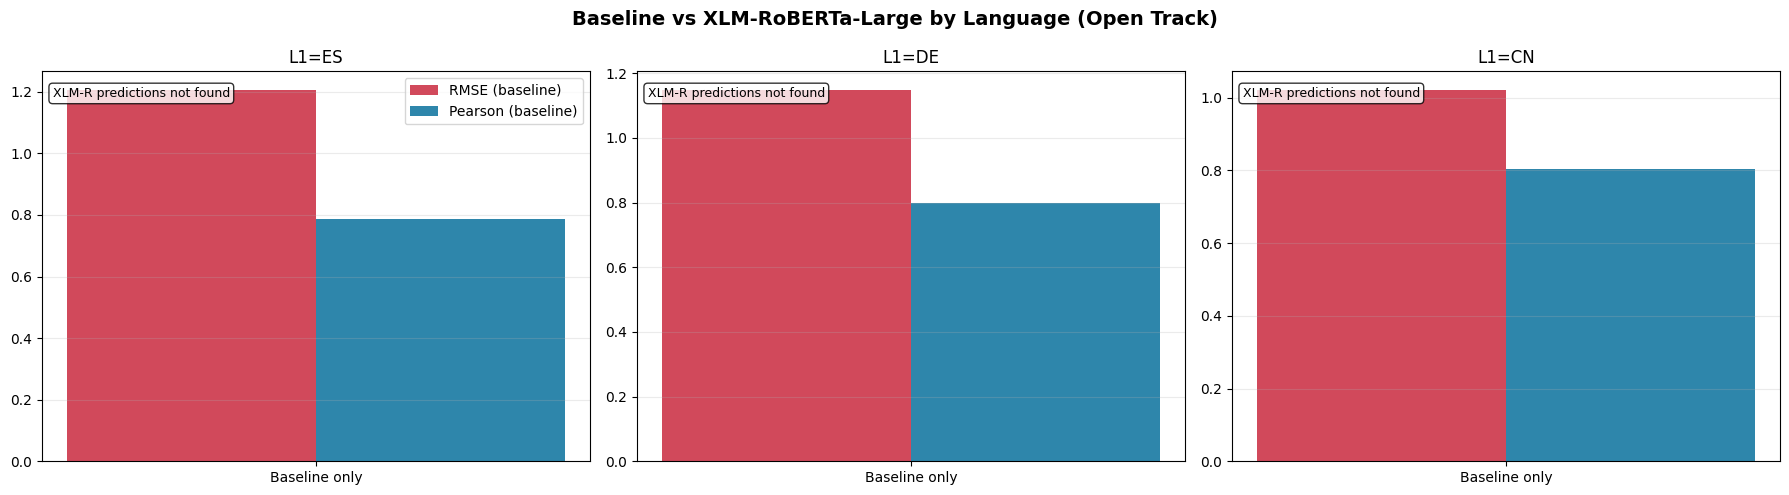

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Explicit comparison by language (open track only): baseline vs xlm-roberta-large
target_track = "open"
target_model = "exp1_open_xlmr_large"
baseline_model = "baseline_open_xx"
l1_order = ["es", "de", "cn"]

subset = all_results[
    (all_results["track"] == target_track)
    & (all_results["model"].isin([baseline_model, target_model]))
].copy()

if subset.empty:
    print("No open-track results found. Run prediction/evaluation first.")
else:
    has_xlmr = (subset["model"] == target_model).any()
    if not has_xlmr:
        print("WARNING: XLM-R results are missing. Showing baseline-only diagnostic plot.")
        print("Expected prediction files: bea2026st/predictions/open/dev/{es,de,cn}/exp1_open_xlmr_large_preds.csv")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
    fig.suptitle("Baseline vs XLM-RoBERTa-Large by Language (Open Track)", fontsize=14, fontweight="bold")

    for i, lang in enumerate(l1_order):
        ax = axes[i]
        lang_df = subset[subset["L1"] == lang].set_index("model")

        if baseline_model not in lang_df.index:
            ax.set_title(f"L1={lang.upper()} (no baseline)")
            ax.axis("off")
            continue

        baseline_rmse = lang_df.loc[baseline_model, "rmse"]
        baseline_pearson = lang_df.loc[baseline_model, "pearson"]

        if target_model in lang_df.index:
            xlmr_rmse = lang_df.loc[target_model, "rmse"]
            xlmr_pearson = lang_df.loc[target_model, "pearson"]

            x = np.arange(2)
            width = 0.35
            ax.bar(x - width / 2, [baseline_rmse, xlmr_rmse], width=width, label="RMSE (lower better)", color="#d1495b")
            ax.bar(x + width / 2, [baseline_pearson, xlmr_pearson], width=width, label="Pearson (higher better)", color="#2e86ab")
            ax.set_xticks(x)
            ax.set_xticklabels(["Baseline", "XLM-R large"])

            delta_rmse = baseline_rmse - xlmr_rmse
            delta_pearson = xlmr_pearson - baseline_pearson
            note = f"Delta RMSE: {delta_rmse:+.4f}\nDelta Pearson: {delta_pearson:+.4f}"
        else:
            # Clean fallback: one pair of baseline bars only
            x = np.arange(1)
            width = 0.35
            ax.bar(x - width / 2, [baseline_rmse], width=width, label="RMSE (baseline)", color="#d1495b")
            ax.bar(x + width / 2, [baseline_pearson], width=width, label="Pearson (baseline)", color="#2e86ab")
            ax.set_xticks(x)
            ax.set_xticklabels(["Baseline only"])
            note = "XLM-R predictions not found"

        ax.set_title(f"L1={lang.upper()}")
        ax.grid(axis="y", alpha=0.25)
        if i == 0:
            ax.legend(loc="best")

        ax.text(
            0.02,
            0.96,
            note,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
        )

    plt.tight_layout()
    plt.show()

In [ ]:
# --- Improvement table: Delta vs baselines ---

# Define baseline references
baseline_ref = {
    ("closed", "es"): {"rmse": 1.357, "pearson": 0.748, "model": "baseline_closed_es"},
    ("closed", "de"): {"rmse": 1.328, "pearson": 0.753, "model": "baseline_closed_de"},
    ("closed", "cn"): {"rmse": 1.175, "pearson": 0.736, "model": "baseline_closed_cn"},
    ("open", "es"): {"rmse": 1.206, "pearson": 0.787, "model": "baseline_open_xx"},
    ("open", "de"): {"rmse": 1.149, "pearson": 0.800, "model": "baseline_open_xx"},
    ("open", "cn"): {"rmse": 1.021, "pearson": 0.804, "model": "baseline_open_xx"},
}

# Only compare non-baseline models
exp_results = all_results[~all_results["model"].str.startswith("baseline")].copy()

deltas = []
for _, row in exp_results.iterrows():
    key = (row["track"], row["L1"])
    if key in baseline_ref:
        ref = baseline_ref[key]
        delta_rmse = ref["rmse"] - row["rmse"]        # Positive = improvement
        delta_pearson = row["pearson"] - ref["pearson"]  # Positive = improvement
        deltas.append({
            "model": row["model"],
            "track": row["track"],
            "L1": row["L1"],
            "rmse": row["rmse"],
            "pearson": row["pearson"],
            "baseline_rmse": ref["rmse"],
            "baseline_pearson": ref["pearson"],
            "Δ_rmse": delta_rmse,
            "Δ_pearson": delta_pearson,
            "improved_rmse": "✓" if delta_rmse > 0 else "✗",
            "improved_pearson": "✓" if delta_pearson > 0 else "✗",
        })

delta_df = pd.DataFrame(deltas)
print("\n" + "="*80)
print("  IMPROVEMENT vs BASELINE (positive Δ = better than baseline)")
print("="*80)

if len(delta_df) > 0:
    print(delta_df[["model", "track", "L1", "rmse", "Δ_rmse", "improved_rmse",
                    "pearson", "Δ_pearson", "improved_pearson"]].round(4).to_string(index=False))
else:
    print("⚠  No experimental results found (only baseline models evaluated).")
    print("   Run Phase 1 experiments (§2–§3) to generate trained model predictions.")


  IMPROVEMENT vs BASELINE (positive Δ = better than baseline)
⚠  No experimental results found (only baseline models evaluated).
   Run Phase 1 experiments (§2–§3) to generate trained model predictions.


In [ ]:
# Save updated results summary
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
all_results.to_csv(RESULTS_DIR / "results_summary_phase1_dev.csv", index=False)

if len(deltas) > 0:
    delta_df.to_csv(RESULTS_DIR / "results_delta_vs_baseline.csv", index=False)

print(f"✓ Results saved to {RESULTS_DIR}")

✓ Results saved to bea2026st\results


## 5. Phase 1 Conclusions / Conclusiones Fase 1

Run the cell below to auto-generate conclusions from experimental results.

In [ ]:
# ==============================================================================
# Auto-generate Phase 1 conclusions from results
# ==============================================================================

try:
    # Load Phase 1 results (generated by §4 evaluation cell)
    phase1_results_path = RESULTS_DIR / "results_summary_phase1_dev.csv"
    baseline_results_path = RESULTS_DIR / "results_summary_dev.csv"

    if phase1_results_path.exists() and baseline_results_path.exists():
        p1_results = pd.read_csv(phase1_results_path)
        bl_results = pd.read_csv(baseline_results_path)

        # Baselines
        bl_open = bl_results[bl_results["track"] == "open"]
        bl_closed = bl_results[bl_results["track"] == "closed"]

        print("=" * 70)
        print("  PHASE 1 CONCLUSIONS / CONCLUSIONES FASE 1")
        print("=" * 70)

        # Best model per category
        print("\n--- Baselines (reference) ---")
        for _, row in bl_open.iterrows():
            print(f"  Open  {row['L1']}: RMSE={row['rmse']:.4f}  Pearson={row['pearson']:.4f}")
        for _, row in bl_closed.iterrows():
            print(f"  Closed {row['L1']}: RMSE={row['rmse']:.4f}  Pearson={row['pearson']:.4f}")

        print("\n--- Phase 1 Experiments ---")
        for _, row in p1_results.iterrows():
            print(f"  {row['model']:30s} L1={row['L1']}  RMSE={row['rmse']:.4f}  Pearson={row['pearson']:.4f}")

        # Best overall
        avg_by_model = p1_results.groupby("model")[["rmse", "pearson"]].mean()
        best = avg_by_model["rmse"].idxmin()
        print(f"\n*** Best Phase 1 model (avg RMSE): {best} ***")
        print(f"    RMSE={avg_by_model.loc[best, 'rmse']:.4f}  Pearson={avg_by_model.loc[best, 'pearson']:.4f}")

        # Improvement vs baseline
        bl_avg_rmse = bl_open["rmse"].mean()
        improvement = bl_avg_rmse - avg_by_model.loc[best, "rmse"]
        print(f"    Improvement vs baseline open (avg): {improvement:+.4f} RMSE")
    else:
        print("⚠ Phase 1 results not yet generated. Run sections §2–§4 first.")
        print(f"  Expected: {phase1_results_path}")
        print(f"  Expected: {baseline_results_path}")
        print("\nPlaceholder conclusions:")
        print("  - Best open track model: [to be determined after running experiments]")
        print("  - Best closed models per L1: [to be determined]")
        print("  - Key finding: [to be determined]")
except Exception as e:
    print(f"⚠ Could not generate conclusions: {e}")
    print("  Run all Phase 1 cells first (§0 through §4).")

  PHASE 1 CONCLUSIONS / CONCLUSIONES FASE 1

--- Baselines (reference) ---
  Open  es: RMSE=1.2061  Pearson=0.7873
  Open  de: RMSE=1.1487  Pearson=0.8004
  Open  cn: RMSE=1.0214  Pearson=0.8042
  Closed cn: RMSE=1.1748  Pearson=0.7355
  Closed de: RMSE=1.3283  Pearson=0.7530
  Closed es: RMSE=1.3569  Pearson=0.7484

--- Phase 1 Experiments ---
  baseline_closed_cn             L1=cn  RMSE=1.1748  Pearson=0.7355
  baseline_closed_de             L1=de  RMSE=1.3283  Pearson=0.7530
  baseline_closed_es             L1=es  RMSE=1.3569  Pearson=0.7484
  baseline_open_xx               L1=es  RMSE=1.2061  Pearson=0.7873
  baseline_open_xx               L1=de  RMSE=1.1487  Pearson=0.8004
  baseline_open_xx               L1=cn  RMSE=1.0214  Pearson=0.8042

*** Best Phase 1 model (avg RMSE): baseline_open_xx ***
    RMSE=1.1254  Pearson=0.7973
    Improvement vs baseline open (avg): +0.0000 RMSE


---

## 6. Phase 2: Linguistic Feature Engineering (Primary Focus)

This section computes and analyzes linguistic features that explain vocabulary difficulty by L1.

Modeling remains fixed to baseline vs XLM-RoBERTa-Large; here we focus on interpretation and feature quality.

### 6.1 Setup & Data Loading

In [ ]:
# ==============================================================================
# Phase 2: Linguistic Feature Engineering - Setup
# ==============================================================================
# Optional heavy features are controlled by flags below.

import re
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import torch

import nltk
from nltk.corpus import wordnet as wn
from nltk.corpus import cmudict

# Flags for optional heavy computations
COMPUTE_COSINE_DISTANCE = False

# Download required NLTK data (quick and cached)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("cmudict", quiet=True)

CMU_DICT = cmudict.dict()

BASE = Path("bea2026st")
dfs = {}
for split in ["train", "dev"]:
    for lang in ["es", "de", "cn"]:
        path = BASE / "data" / split / lang / f"kvl_shared_task_{lang}_{split}.csv"
        dfs[(split, lang)] = pd.read_csv(path)

train = pd.concat([dfs[("train", l)] for l in ["es", "de", "cn"]], ignore_index=True)
dev = pd.concat([dfs[("dev", l)] for l in ["es", "de", "cn"]], ignore_index=True)

print(f"Train: {len(train):,} rows | Dev: {len(dev):,} rows")
print(f"CMU Dict entries: {len(CMU_DICT):,}")
print(f"WordNet synsets: {len(list(wn.all_synsets())):,}")
print(f"COMPUTE_COSINE_DISTANCE={COMPUTE_COSINE_DISTANCE}")

Train: 18,273 rows | Dev: 2,031 rows
CMU Dict entries: 123,455
WordNet synsets: 117,659
COMPUTE_COSINE_DISTANCE=False


### 6.2 Basic Orthographic Features

**Word length** and **clue ratio** — the simplest but strongest predictors from EDA (r ≈ -0.38 with GLMM_score).

In [ ]:
# ==============================================================================
# Feature 1: Word Length
# Feature 2: Clue Ratio (proportion of hidden letters)
# ==============================================================================

def compute_basic_features(df):
    """Compute word length and clue-related features."""
    df = df.copy()
    df["word_length"] = df["en_target_word"].str.len()
    df["clue_blanks"] = df["en_target_clue"].str.count("_")
    df["clue_ratio"] = df["clue_blanks"] / df["word_length"]
    return df

train = compute_basic_features(train)
dev = compute_basic_features(dev)

print("Basic features computed:")
print(train[["en_target_word", "word_length", "clue_blanks", "clue_ratio"]].head(10).to_string(index=False))
print(f"\nCorrelation with GLMM_score:")
print(f"  word_length: {train['word_length'].corr(train['GLMM_score']):.4f}")
print(f"  clue_ratio:  {train['clue_ratio'].corr(train['GLMM_score']):.4f}")

Basic features computed:
en_target_word  word_length  clue_blanks  clue_ratio
          span            4            3    0.750000
     radically            9            8    0.888889
   supermarket           11           10    0.909091
      airplane            8            7    0.875000
        trying            6            5    0.833333
        racing            6            5    0.833333
         sleep            5            4    0.800000
      military            8            7    0.875000
      capacity            8            7    0.875000
          cane            4            3    0.750000

Correlation with GLMM_score:
  word_length: -0.3687
  clue_ratio:  -0.3815


### 6.3 Polysemy & Homonymy (WordNet)

**Polysemy:** Number of synsets (distinct senses) a word has in WordNet. Polysemous words have more meanings, which can:
- Make them **easier** (more exposure contexts for learners)
- Make them **harder** (meaning disambiguation difficulty)

**Homonymy:** Whether a word has senses spanning **multiple POS categories** in WordNet, indicating potentially unrelated meanings (e.g., "bank" as noun vs verb).

> *"Polysemy and homonymy are central factors in vocabulary acquisition difficulty, as words with multiple meanings impose additional cognitive load on learners who must disambiguate context."* — Jarvis & Pavlenko (2008)

In [ ]:
# ==============================================================================
# Feature 3: Polysemy Count (number of WordNet synsets)
# Feature 4: Homonymy Flag (senses across multiple POS)
# ==============================================================================

# Map our POS tags to WordNet POS
POS_MAP = {
    "noun": wn.NOUN,
    "verb": wn.VERB,
    "adjective": wn.ADJ,
    "adverb": wn.ADV,
}

def polysemy_count(word):
    """Total number of synsets for the word across all POS."""
    return len(wn.synsets(word, lang="eng"))

def polysemy_count_pos(word, pos):
    """Number of synsets for the word in its specific POS."""
    wn_pos = POS_MAP.get(pos)
    if wn_pos:
        return len(wn.synsets(word, pos=wn_pos, lang="eng"))
    return len(wn.synsets(word, lang="eng"))

def homonymy_flag(word):
    """
    1 if the word has synsets in more than one POS category, else 0.
    This approximates homonymy (same form, different POS = likely unrelated meanings).
    """
    synsets = wn.synsets(word, lang="eng")
    pos_set = set(s.pos() for s in synsets)
    return int(len(pos_set) > 1)

def homonymy_pos_count(word):
    """Number of distinct POS categories the word appears in (WordNet)."""
    synsets = wn.synsets(word, lang="eng")
    return len(set(s.pos() for s in synsets))

# Apply to data
for df_name, df in [("train", train), ("dev", dev)]:
    df["polysemy_all"] = df["en_target_word"].apply(polysemy_count)
    df["polysemy_pos"] = df.apply(lambda r: polysemy_count_pos(r["en_target_word"], r["en_target_pos"]), axis=1)
    df["is_homonym"] = df["en_target_word"].apply(homonymy_flag)
    df["homonym_pos_count"] = df["en_target_word"].apply(homonymy_pos_count)

print("Polysemy & Homonymy features:")
sample = train[["en_target_word", "en_target_pos", "polysemy_all", "polysemy_pos", "is_homonym", "homonym_pos_count", "GLMM_score"]].drop_duplicates("en_target_word").head(15)
print(sample.to_string(index=False))

print(f"\nCorrelation with GLMM_score:")
for col in ["polysemy_all", "polysemy_pos", "is_homonym", "homonym_pos_count"]:
    print(f"  {col}: {train[col].corr(train['GLMM_score']):.4f}")

print(f"\nHomonyms: {train['is_homonym'].sum():,} / {len(train):,} ({100*train['is_homonym'].mean():.1f}%)")
print(f"Mean polysemy (all): {train['polysemy_all'].mean():.2f} | Median: {train['polysemy_all'].median():.0f}")

Polysemy & Homonymy features:
en_target_word en_target_pos  polysemy_all  polysemy_pos  is_homonym  homonym_pos_count  GLMM_score
          span          noun             7             6           1                  2   -3.264099
     radically        adverb             1             1           0                  1   -1.871782
   supermarket          noun             1             1           0                  1    2.733109
      airplane          noun             1             1           0                  1    0.054737
        trying     adjective            11             2           1                  2   -4.086776
        racing          noun             5             1           1                  2   -0.071782
         sleep          verb             6             2           1                  2    3.682800
      military          noun             4             1           1                  2   -0.086130
      capacity          noun             9             9           0  

### 6.4 Consonant Clusters & Rhotacism

**Consonant clusters** are sequences of 2+ consonant letters without intervening vowels (e.g., "str" in "strength", "ght" in "knight"). Their difficulty varies dramatically by L1:
- **Mandarin (cn):** Has virtually no consonant clusters in native phonology → extremely challenging
- **German (de):** Rich consonant cluster inventory → relatively easy
- **Spanish (es):** Limited clusters (mostly 2-consonant onsets) → moderately challenging

**Rhotacism** refers to the difficulty of producing and perceiving the English /r/ phoneme. The realization of /r/ varies greatly across languages:
- **Mandarin:** /r/ is realized as a retroflex approximant [ɻ], quite different from English
- **Spanish:** Uses trilled /r/ [r] and tap [ɾ], distinct from English approximant [ɹ]
- **German:** Uses uvular /r/ [ʁ], which differs from English

We create **L1-weighted rhotacism** scores reflecting the expected difficulty.

In [ ]:
# ==============================================================================
# Feature 7 & 8: Consonant Cluster Count & Max Cluster Length
# Feature 9: Rhotacism Indicator (with L1-weighted difficulty)
# ==============================================================================

VOWELS = set("aeiou")

def consonant_clusters(word):
    """
    Find all consonant clusters (sequences of 2+ consonants) in a word.
    Returns list of cluster strings.
    """
    word_lower = word.lower()
    clusters = re.findall(r'[^aeiou]{2,}', word_lower)
    # Filter out clusters that are only non-alpha characters
    clusters = [c for c in clusters if any(ch.isalpha() for ch in c)]
    return clusters

def n_consonant_clusters(word):
    """Count of consonant clusters (≥2 consecutive consonants)."""
    return len(consonant_clusters(word))

def max_cluster_length(word):
    """Length of the longest consonant cluster."""
    clusters = consonant_clusters(word)
    return max(len(c) for c in clusters) if clusters else 0

def has_r_phoneme(word):
    """Check if the word contains an /r/ phoneme (using CMU dict)."""
    word_lower = word.lower()
    if word_lower in CMU_DICT:
        phonemes = CMU_DICT[word_lower][0]  # Take first pronunciation
        return int(any("R" in p for p in phonemes))
    # Fallback: check if 'r' appears in spelling
    return int("r" in word_lower)

def count_r_phonemes(word):
    """Count occurrences of /r/ phoneme in the word."""
    word_lower = word.lower()
    if word_lower in CMU_DICT:
        phonemes = CMU_DICT[word_lower][0]
        return sum(1 for p in phonemes if "R" in p)
    return word_lower.count("r")

# L1-specific rhotacism difficulty weights
# Higher = more difficulty with English /r/
RHOTACISM_WEIGHT = {
    "cn": 0.9,   # Mandarin: very different /r/ realization
    "es": 0.7,   # Spanish: trilled/tap /r/ vs English approximant
    "de": 0.5,   # German: uvular /r/, less problematic
}

for df in [train, dev]:
    df["n_consonant_clusters"] = df["en_target_word"].apply(n_consonant_clusters)
    df["max_cluster_length"] = df["en_target_word"].apply(max_cluster_length)
    df["has_r"] = df["en_target_word"].apply(has_r_phoneme)
    df["r_count"] = df["en_target_word"].apply(count_r_phonemes)
    df["rhotacism_weighted"] = df["r_count"] * df["L1"].map(RHOTACISM_WEIGHT)

# Display examples
print("Consonant Clusters & Rhotacism:")
sample_words = ["strength", "knight", "church", "airplane", "supermarket", "span", "eye", "rhythm"]
for w in sample_words:
    clusters = consonant_clusters(w)
    r_flag = has_r_phoneme(w)
    print(f"  {w:15s} → clusters: {clusters!s:25s} | max_len: {max_cluster_length(w)} | has_r: {r_flag} | r_count: {count_r_phonemes(w)}")

print(f"\nCorrelation with GLMM_score:")
for col in ["n_consonant_clusters", "max_cluster_length", "has_r", "r_count", "rhotacism_weighted"]:
    print(f"  {col}: {train[col].corr(train['GLMM_score']):.4f}")

Consonant Clusters & Rhotacism:
  strength        → clusters: ['str', 'ngth']           | max_len: 4 | has_r: 1 | r_count: 1
  knight          → clusters: ['kn', 'ght']             | max_len: 3 | has_r: 0 | r_count: 0
  church          → clusters: ['ch', 'rch']             | max_len: 3 | has_r: 1 | r_count: 1
  airplane        → clusters: ['rpl']                   | max_len: 3 | has_r: 1 | r_count: 1
  supermarket     → clusters: ['rm', 'rk']              | max_len: 2 | has_r: 1 | r_count: 2
  span            → clusters: ['sp']                    | max_len: 2 | has_r: 0 | r_count: 0
  eye             → clusters: []                        | max_len: 0 | has_r: 0 | r_count: 0
  rhythm          → clusters: ['rhythm']                | max_len: 6 | has_r: 1 | r_count: 1

Correlation with GLMM_score:
  n_consonant_clusters: -0.2435
  max_cluster_length: -0.1799
  has_r: -0.0836
  r_count: -0.0944
  rhotacism_weighted: -0.0920


### 6.5 Aphthong (Silent Letters) & Spelling Opacity

An **aphthong** is a letter in the spelling of a word that has no corresponding phoneme in its pronunciation (a "silent letter"). English has notoriously opaque orthography with many aphthongs:
- "**k**night" → /naɪt/ (silent **k**, **gh**)
- "**w**rite" → /raɪt/ (silent **w**)
- "**p**sychology" → /saɪˈkɒlədʒi/ (silent **p**)

We use the **CMU Pronouncing Dictionary** to compare:
- Number of **letters** in the word (graphemes)
- Number of **phonemes** in the pronunciation

The **spelling–phoneme ratio** (`n_letters / n_phonemes`) captures orthographic opacity. A ratio > 1.0 indicates more letters than phonemes (i.e., silent letters or digraphs). Higher opacity → harder for learners.

In [ ]:
# ==============================================================================
# Feature 10: Aphthong / Silent Letters
# Feature 12: Phoneme count
# Feature 13: Spelling-Phoneme Ratio (orthographic opacity)
# ==============================================================================

def phoneme_count(word):
    """Number of phonemes from CMU dict. Returns NaN if word not found."""
    word_lower = word.lower()
    if word_lower in CMU_DICT:
        return len(CMU_DICT[word_lower][0])
    return np.nan

def silent_letter_count(word):
    """
    Estimate number of 'silent letters' (aphthongs).
    Computed as: n_letters - n_phonemes (when n_letters > n_phonemes).
    This is an approximation: digraphs (sh, th, ch) also contribute to the
    difference, but the overall ratio still captures orthographic opacity.
    """
    n_letters = len(word)
    n_phonemes = phoneme_count(word)
    if np.isnan(n_phonemes):
        return np.nan
    diff = n_letters - n_phonemes
    return max(diff, 0)  # Can't have negative silent letters

def spelling_phoneme_ratio(word):
    """Ratio of letters to phonemes. >1.0 means opaque orthography."""
    n_letters = len(word)
    n_phonemes = phoneme_count(word)
    if np.isnan(n_phonemes) or n_phonemes == 0:
        return np.nan
    return n_letters / n_phonemes

for df in [train, dev]:
    df["n_phonemes"] = df["en_target_word"].apply(phoneme_count)
    df["silent_letters"] = df["en_target_word"].apply(silent_letter_count)
    df["spelling_phoneme_ratio"] = df["en_target_word"].apply(spelling_phoneme_ratio)

# Coverage
cmu_coverage = train["n_phonemes"].notna().mean()
print(f"CMU Dictionary coverage: {cmu_coverage:.1%} of words")

# Examples
print("\nAphthong / Spelling Opacity examples:")
examples = ["knight", "write", "psychology", "cat", "through", "yacht", "rhythm", "supermarket"]
for w in examples:
    n_ph = phoneme_count(w)
    sl = silent_letter_count(w)
    ratio = spelling_phoneme_ratio(w)
    pron = CMU_DICT.get(w.lower(), [["?"]])[0]
    print(f"  {w:15s} → letters: {len(w):2d} | phonemes: {str(n_ph):>4s} | silent: {str(sl):>4s} | ratio: {str(round(ratio,2)) if not np.isnan(ratio) else 'N/A':>5s} | pron: {' '.join(pron)}")

print(f"\nCorrelation with GLMM_score:")
for col in ["n_phonemes", "silent_letters", "spelling_phoneme_ratio"]:
    r = train[col].corr(train["GLMM_score"])
    print(f"  {col}: {r:.4f}")

CMU Dictionary coverage: 99.2% of words

Aphthong / Spelling Opacity examples:
  knight          → letters:  6 | phonemes:    3 | silent:    3 | ratio:   2.0 | pron: N AY1 T
  write           → letters:  5 | phonemes:    3 | silent:    2 | ratio:  1.67 | pron: R AY1 T
  psychology      → letters: 10 | phonemes:    8 | silent:    2 | ratio:  1.25 | pron: S AY0 K AA1 L AH0 JH IY0
  cat             → letters:  3 | phonemes:    3 | silent:    0 | ratio:   1.0 | pron: K AE1 T
  through         → letters:  7 | phonemes:    3 | silent:    4 | ratio:  2.33 | pron: TH R UW1
  yacht           → letters:  5 | phonemes:    3 | silent:    2 | ratio:  1.67 | pron: Y AA1 T
  rhythm          → letters:  6 | phonemes:    5 | silent:    1 | ratio:   1.2 | pron: R IH1 DH AH0 M
  supermarket     → letters: 11 | phonemes:   10 | silent:    1 | ratio:   1.1 | pron: S UW1 P ER0 M AA2 R K IH0 T

Correlation with GLMM_score:
  n_phonemes: -0.3533
  silent_letters: -0.0783
  spelling_phoneme_ratio: 0.0771


### 6.6 Letters Absent from L1 Alphabet / Writing System

For each English target word, we count how many of its letters **do not appear** in the L1's native alphabet or typical writing conventions. This captures **orthographic unfamiliarity**:

- **Spanish (es):** Nearly identical alphabet to English; main differences: Spanish rarely uses **k, w** natively. Letters like **y** have different frequency.
- **German (de):** Also Latin script; uses umlauts (ä, ö, ü) and ß but recognizes all English letters. Very few unfamiliar letters.
- **Mandarin (cn):** Uses **Chinese characters (hanzi)** as the primary writing system. English letters are entirely foreign, though learners are exposed to Pinyin romanization. We compute a different metric: how many letters in the English word are **low-frequency in Pinyin**, indicating less familiarity.

In [ ]:
# ==============================================================================
# Feature 6: Letters Absent from L1 Alphabet / Writing System
# ==============================================================================

# Define which English letters are "unfamiliar" or rare for each L1 background.
# These are letters that learners are less likely to have motor/visual familiarity with.

# Spanish: nearly identical Latin alphabet; 'k' and 'w' are marginal
ES_UNFAMILIAR = set("kw")

# German: full Latin alphabet overlap; nothing truly unfamiliar
DE_UNFAMILIAR = set()  # German uses all 26 English letters

# Mandarin: Pinyin uses Latin script but certain letters are very rare or absent
# Letters rare/absent in Pinyin: v (only in foreign words, some dialects use ü instead)
# Low-frequency Pinyin letters: approximated by letters rarely seen in Pinyin syllables
CN_RARE_IN_PINYIN = set("v")
# For Mandarin, we instead compute a "script distance" — all Latin letters are foreign
# relative to hanzi, so we compute a Pinyin-frequency-weighted penalty.

# Pinyin letter frequency (approximate, based on standard Pinyin syllable tables)
PINYIN_LETTER_FREQ = {
    'a': 0.12, 'b': 0.04, 'c': 0.03, 'd': 0.04, 'e': 0.08, 'f': 0.02,
    'g': 0.04, 'h': 0.05, 'i': 0.11, 'j': 0.03, 'k': 0.02, 'l': 0.04,
    'm': 0.03, 'n': 0.08, 'o': 0.06, 'p': 0.03, 'q': 0.02, 'r': 0.02,
    's': 0.03, 't': 0.03, 'u': 0.08, 'v': 0.00, 'w': 0.02, 'x': 0.02,
    'y': 0.03, 'z': 0.03,
}

UNFAMILIAR_MAP = {
    "es": ES_UNFAMILIAR,
    "de": DE_UNFAMILIAR,
}

def count_unfamiliar_letters(word, l1):
    """Count letters in English word that are unfamiliar/rare for the L1."""
    word_lower = word.lower()

    if l1 in UNFAMILIAR_MAP:
        unfamiliar_set = UNFAMILIAR_MAP[l1]
        return sum(1 for ch in word_lower if ch in unfamiliar_set)

    elif l1 == "cn":
        # For Mandarin: compute inverse-Pinyin-frequency score
        # Letters rare in Pinyin get higher penalty
        score = 0
        for ch in word_lower:
            if ch.isalpha():
                freq = PINYIN_LETTER_FREQ.get(ch, 0.0)
                score += (1.0 - freq)  # Inverse frequency as penalty
        return round(score, 2)

    return 0

def has_unfamiliar_letters(word, l1):
    """Binary flag: does the word contain any L1-unfamiliar letters?"""
    return int(count_unfamiliar_letters(word, l1) > 0)

for df in [train, dev]:
    df["unfamiliar_letters"] = df.apply(
        lambda r: count_unfamiliar_letters(r["en_target_word"], r["L1"]), axis=1
    )
    df["has_unfamiliar"] = df.apply(
        lambda r: has_unfamiliar_letters(r["en_target_word"], r["L1"]), axis=1
    )

# Display by L1
print("Unfamiliar letters by L1:")
for lang in ["es", "de", "cn"]:
    subset = train[train["L1"] == lang]
    print(f"\n  L1={lang}:")
    print(f"    Mean unfamiliar score: {subset['unfamiliar_letters'].mean():.3f}")
    print(f"    Words with unfamiliar letters: {subset['has_unfamiliar'].sum():,} / {len(subset):,} ({100*subset['has_unfamiliar'].mean():.1f}%)")

# Example
print("\nExamples:")
for word in ["knight", "walk", "kwanzaa", "supermarket", "rhythm"]:
    for l1 in ["es", "de", "cn"]:
        score = count_unfamiliar_letters(word, l1)
        print(f"  {word:15s} (L1={l1}) → unfamiliar score: {score}")

print(f"\nCorrelation with GLMM_score:")
print(f"  unfamiliar_letters: {train['unfamiliar_letters'].corr(train['GLMM_score']):.4f}")
print(f"  has_unfamiliar:     {train['has_unfamiliar'].corr(train['GLMM_score']):.4f}")

Unfamiliar letters by L1:

  L1=es:
    Mean unfamiliar score: 0.127
    Words with unfamiliar letters: 712 / 6,091 (11.7%)

  L1=de:
    Mean unfamiliar score: 0.000
    Words with unfamiliar letters: 0 / 6,091 (0.0%)

  L1=cn:
    Mean unfamiliar score: 6.781
    Words with unfamiliar letters: 6,091 / 6,091 (100.0%)

Examples:
  knight          (L1=es) → unfamiliar score: 1
  knight          (L1=de) → unfamiliar score: 0
  knight          (L1=cn) → unfamiliar score: 5.67
  walk            (L1=es) → unfamiliar score: 2
  walk            (L1=de) → unfamiliar score: 0
  walk            (L1=cn) → unfamiliar score: 3.8
  kwanzaa         (L1=es) → unfamiliar score: 2
  kwanzaa         (L1=de) → unfamiliar score: 0
  kwanzaa         (L1=cn) → unfamiliar score: 6.49
  supermarket     (L1=es) → unfamiliar score: 1
  supermarket     (L1=de) → unfamiliar score: 0
  supermarket     (L1=cn) → unfamiliar score: 10.46
  rhythm          (L1=es) → unfamiliar score: 0
  rhythm          (L1=de) → unfam

### 6.7 Syntactic Overlap (L1 ↔ English)

**Syntactic overlap** captures how well the grammatical role of the target word aligns between the learner's L1 and English. We encode typological knowledge about word order, morphological complexity, and POS-level transfer difficulty:

- **Spanish (es):** SVO word order like English; adjectives typically follow nouns (unlike English). Verb morphology is richer → verbs may be harder to map.
- **German (de):** V2 word order, SOV in subordinate clauses. Flexible word order → some POS confusion. Compound nouns are common → English multi-word expressions harder.
- **Mandarin (cn):** SVO like English but isolating language (no morphological inflection). POS boundaries are more fluid → adjectives and verbs may be confused.

In [ ]:
# ==============================================================================
# Feature 11: Syntactic Overlap (L1 ↔ English)
# ==============================================================================

# Typological POS-level transfer difficulty scores (0 = easy transfer, 1 = hard)
# Based on contrastive linguistics literature
# Rows: L1, Columns: English POS

SYNTACTIC_DIFFICULTY = {
    "es": {
        "noun": 0.2,       # Similar noun systems, gender mismatch doesn't affect English
        "verb": 0.5,       # Richer morphology in Spanish → mapping to English simpler forms
        "adjective": 0.4,  # Post-nominal in Spanish, pre-nominal in English
        "adverb": 0.2,     # Similar placement rules
        "number": 0.1,     # Numbers transfer easily
        "determiner": 0.3, # Article system exists in both, some differences
        "preposition": 0.4, # Different prepositional usage patterns
    },
    "de": {
        "noun": 0.3,       # German capitalizes nouns; compound nouns very different
        "verb": 0.6,       # V2 and SOV word order → verb placement confusion
        "adjective": 0.3,  # Pre-nominal like English, but inflected
        "adverb": 0.3,     # Different placement in V2 structures
        "number": 0.1,     # Numbers transfer easily
        "determiner": 0.4, # Case system in German, complex article usage
        "preposition": 0.5, # Case-governing prepositions → different L1 patterns
    },
    "cn": {
        "noun": 0.4,       # Classifier system in Mandarin, no plural marking
        "verb": 0.7,       # No conjugation in Mandarin → English tense system hard
        "adjective": 0.5,  # Adjectives vs stative verbs fluid boundary in Mandarin
        "adverb": 0.3,     # Relatively similar placement
        "number": 0.2,     # Number systems differ (万 vs thousand grouping)
        "determiner": 0.6, # No articles in Mandarin → English articles very hard
        "preposition": 0.5, # Coverbs vs prepositions — different conceptualization
    },
}

def syntactic_overlap_score(pos, l1):
    """
    Return the syntactic transfer difficulty score for a given POS and L1.
    Higher = more difficult syntactic mapping between L1 and English.
    """
    l1_scores = SYNTACTIC_DIFFICULTY.get(l1, {})
    return l1_scores.get(pos, 0.5)  # Default to 0.5 for unknown POS

for df in [train, dev]:
    df["syntactic_difficulty"] = df.apply(
        lambda r: syntactic_overlap_score(r["en_target_pos"], r["L1"]), axis=1
    )

print("Syntactic Difficulty by L1 and POS:")
pivot = train.groupby(["L1", "en_target_pos"])["syntactic_difficulty"].first().unstack(fill_value=0.5)
print(pivot.round(2).to_string())

print(f"\nCorrelation with GLMM_score: {train['syntactic_difficulty'].corr(train['GLMM_score']):.4f}")

print(f"\nMean syntactic difficulty by L1:")
for lang in ["es", "de", "cn"]:
    subset = train[train["L1"] == lang]
    print(f"  {lang}: {subset['syntactic_difficulty'].mean():.3f}")

Syntactic Difficulty by L1 and POS:
en_target_pos  adjective  adverb  determiner  misc  not-no  noun  number  preposition  verb
L1                                                                                         
cn                   0.5     0.3         0.6   0.5     0.5   0.4     0.2          0.5   0.7
de                   0.3     0.3         0.4   0.5     0.5   0.3     0.1          0.5   0.6
es                   0.4     0.2         0.3   0.5     0.5   0.2     0.1          0.4   0.5

Correlation with GLMM_score: -0.0428

Mean syntactic difficulty by L1:
  es: 0.298
  de: 0.352
  cn: 0.468


### 6.8 Cosine Distance (L1 ↔ English) — Multilingual Embeddings

The **cosine distance** between the L1 source word and the English target word in a shared multilingual embedding space captures **semantic proximity** across languages. Words that are semantically close in the embedding space (cognates, direct translations) should be easier for learners, while distant embeddings suggest conceptual mismatch or false friends.

We use **sentence-transformers** with a multilingual model (`paraphrase-multilingual-MiniLM-L12-v2`) to embed both `L1_source_word` and `en_target_word` and compute cosine distance.

> **Note:** This feature is L1-specific by design — the same English word has different cosine distances depending on the L1 source word.

In [ ]:
# ==============================================================================
# Feature 5: Cosine Distance between L1 source word and EN target word
# ==============================================================================
# Heavy block: downloads and runs multilingual embeddings.

if not COMPUTE_COSINE_DISTANCE:
    train["cosine_dist_l1_en"] = np.nan
    dev["cosine_dist_l1_en"] = np.nan
    print("Skipped cosine distance computation (COMPUTE_COSINE_DISTANCE=False).")
else:
    from sentence_transformers import SentenceTransformer
    from scipy.spatial.distance import cosine as cosine_distance

    device = "cuda" if torch.cuda.is_available() else "cpu"
    ST_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
    print(f"Loading {ST_MODEL_NAME} on {device}...")
    st_model = SentenceTransformer(ST_MODEL_NAME, device=device)
    print(f"Model loaded on {st_model.device}")

    def compute_cosine_distances(df, model, batch_size=512):
        df = df.copy()
        en_words = df["en_target_word"].tolist()
        l1_words = df["L1_source_word"].astype(str).tolist()

        print(f"  Encoding {len(en_words):,} English words...")
        en_embeddings = model.encode(en_words, batch_size=batch_size, show_progress_bar=True)

        print(f"  Encoding {len(l1_words):,} L1 source words...")
        l1_embeddings = model.encode(l1_words, batch_size=batch_size, show_progress_bar=True)

        distances = []
        for en_emb, l1_emb in zip(en_embeddings, l1_embeddings):
            distances.append(float(cosine_distance(en_emb, l1_emb)))

        df["cosine_dist_l1_en"] = distances
        return df

    print("Computing cosine distances for train set...")
    train = compute_cosine_distances(train, st_model)
    print("\nComputing cosine distances for dev set...")
    dev = compute_cosine_distances(dev, st_model)

    print("\nCosine distance statistics:")
    for lang in ["es", "de", "cn"]:
        subset = train[train["L1"] == lang]
        print(
            f"  L1={lang}: mean={subset['cosine_dist_l1_en'].mean():.4f}, "
            f"std={subset['cosine_dist_l1_en'].std():.4f}, "
            f"median={subset['cosine_dist_l1_en'].median():.4f}"
        )

    print("\nCorrelation with GLMM_score:")
    print(f"  cosine_dist_l1_en: {train['cosine_dist_l1_en'].corr(train['GLMM_score']):.4f}")

    del st_model
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()
    print("Model unloaded.")

Skipped cosine distance computation (COMPUTE_COSINE_DISTANCE=False).


### 6.9 Additional Linguistic Features

Three new features that were identified as potentially impactful but not previously implemented:

| Feature | Source | Rationale |
|---------|--------|-----------|
| **Word frequency** | WordNet lemma counts (proxy for SUBTLEX) | More frequent words are easier to recall and produce |
| **Levenshtein distance** | `editdistance` library | Normalized edit distance between L1 source and EN target — captures cognate similarity |
| **Morphological complexity** | English suffix heuristics | Count of identifiable morphemes — more complex morphology = harder |

In [ ]:
# ==============================================================================
# Feature Set 3: Word Frequency, Levenshtein Distance, Morphological Complexity
# ==============================================================================

# Pure Python Levenshtein distance (no external dependencies needed)
def levenshtein_distance(s1, s2):
    """Compute Levenshtein distance using dynamic programming."""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)

    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row

    return previous_row[-1]

# ---------- Feature 1: Word Frequency (WordNet lemma counts as proxy) ----------
# Using WordNet total lemma frequency count across all synsets as a
# corpus-independent frequency proxy. log10(count + 1) for scaling.

def wordnet_frequency(word):
    """Sum the count() of all lemmas matching this word in WordNet."""
    lemmas = wn.lemmas(word.lower())
    total = sum(lemma.count() for lemma in lemmas)
    return np.log10(total + 1)

for df in [train, dev]:
    df["word_frequency"] = df["en_target_word"].apply(wordnet_frequency)

print("Word frequency (log10) computed:")
print(f"  Mean: {train['word_frequency'].mean():.3f}, Std: {train['word_frequency'].std():.3f}")
print(f"  Correlation with GLMM_score: {train['word_frequency'].corr(train['GLMM_score']):.4f}")
print(f"  Examples:")
for w in ["the", "cat", "ephemeral", "rhythm", "house"]:
    print(f"    {w:15s} → freq={wordnet_frequency(w):.3f}")

# ---------- Feature 2: Levenshtein Distance (Cognate Detection) ----------
# Normalized edit distance between L1 source word and EN target word.
# Lower distance = more similar (likely cognate) = potentially easier.
# Normalized by max(len(w1), len(w2)) to make comparable across word lengths.

def normalized_levenshtein(w1, w2):
    """Compute normalized Levenshtein distance between two strings."""
    w1, w2 = str(w1).lower(), str(w2).lower()
    max_len = max(len(w1), len(w2))
    if max_len == 0:
        return 0.0
    return levenshtein_distance(w1, w2) / max_len

for df in [train, dev]:
    df["levenshtein_dist"] = df.apply(
        lambda r: normalized_levenshtein(r["en_target_word"], r["L1_source_word"]), axis=1
    )

print(f"\nLevenshtein distance (normalized) computed:")
for lang in ["es", "de", "cn"]:
    subset = train[train["L1"] == lang]
    r = subset["levenshtein_dist"].corr(subset["GLMM_score"])
    print(f"  L1={lang}: mean={subset['levenshtein_dist'].mean():.3f}, "
          f"std={subset['levenshtein_dist'].std():.3f}, "
          f"corr with GLMM={r:+.4f}")

# ---------- Feature 3: Morphological Complexity ----------
# Heuristic morpheme counter based on common English affixes.
# Counts number of recognized prefixes + suffixes + 1 (for stem).

PREFIXES = [
    "un", "re", "in", "im", "ir", "il", "dis", "en", "em",
    "non", "over", "mis", "sub", "pre", "inter", "fore",
    "de", "trans", "super", "semi", "anti", "mid", "under",
]
SUFFIXES = [
    "tion", "sion", "ment", "ness", "ity", "able", "ible",
    "ful", "less", "ous", "ive", "al", "ly", "er", "or",
    "ist", "ism", "ing", "ed", "en", "ize", "ise", "ate",
    "ary", "ery", "ory", "dom", "ship", "ward",
]

def morphological_complexity(word):
    """Estimate morpheme count via prefix/suffix matching heuristic."""
    word_lower = word.lower()
    if len(word_lower) < 4:
        return 1  # too short for affixes

    morphemes = 1  # base stem

    # Check prefixes (longest match first)
    for prefix in sorted(PREFIXES, key=len, reverse=True):
        if word_lower.startswith(prefix) and len(word_lower) > len(prefix) + 2:
            morphemes += 1
            word_lower = word_lower[len(prefix):]
            break

    # Check suffixes (longest match first)
    for suffix in sorted(SUFFIXES, key=len, reverse=True):
        if word_lower.endswith(suffix) and len(word_lower) > len(suffix) + 1:
            morphemes += 1
            break

    return morphemes

for df in [train, dev]:
    df["morphological_complexity"] = df["en_target_word"].apply(morphological_complexity)

print(f"\nMorphological complexity computed:")
print(f"  Value distribution:\n{train['morphological_complexity'].value_counts().sort_index().to_string()}")
print(f"  Correlation with GLMM_score: {train['morphological_complexity'].corr(train['GLMM_score']):.4f}")
print(f"\n  Examples:")
for w in ["unhappiness", "cat", "international", "rethinking", "dog", "misunderstanding"]:
    print(f"    {w:20s} → morphemes={morphological_complexity(w)}")

Word frequency (log10) computed:
  Mean: 0.971, Std: 0.663
  Correlation with GLMM_score: 0.3141
  Examples:
    the             → freq=0.000
    cat             → freq=1.279
    ephemeral       → freq=0.301
    rhythm          → freq=1.230
    house           → freq=2.260

Levenshtein distance (normalized) computed:
  L1=es: mean=0.733, std=0.243, corr with GLMM=-0.2453
  L1=de: mean=0.712, std=0.267, corr with GLMM=-0.3684
  L1=cn: mean=0.999, std=0.016, corr with GLMM=+0.0669

Morphological complexity computed:
  Value distribution:
morphological_complexity
1    9267
2    7350
3    1656
  Correlation with GLMM_score: -0.2551

  Examples:
    unhappiness          → morphemes=3
    cat                  → morphemes=1
    international        → morphemes=3
    rethinking           → morphemes=3
    dog                  → morphemes=1
    misunderstanding     → morphemes=3


### 6.9 Feature Summary & Correlation Analysis

Comprehensive view of all engineered features and their relationship with `GLMM_score`.

Available features: 17 / 17


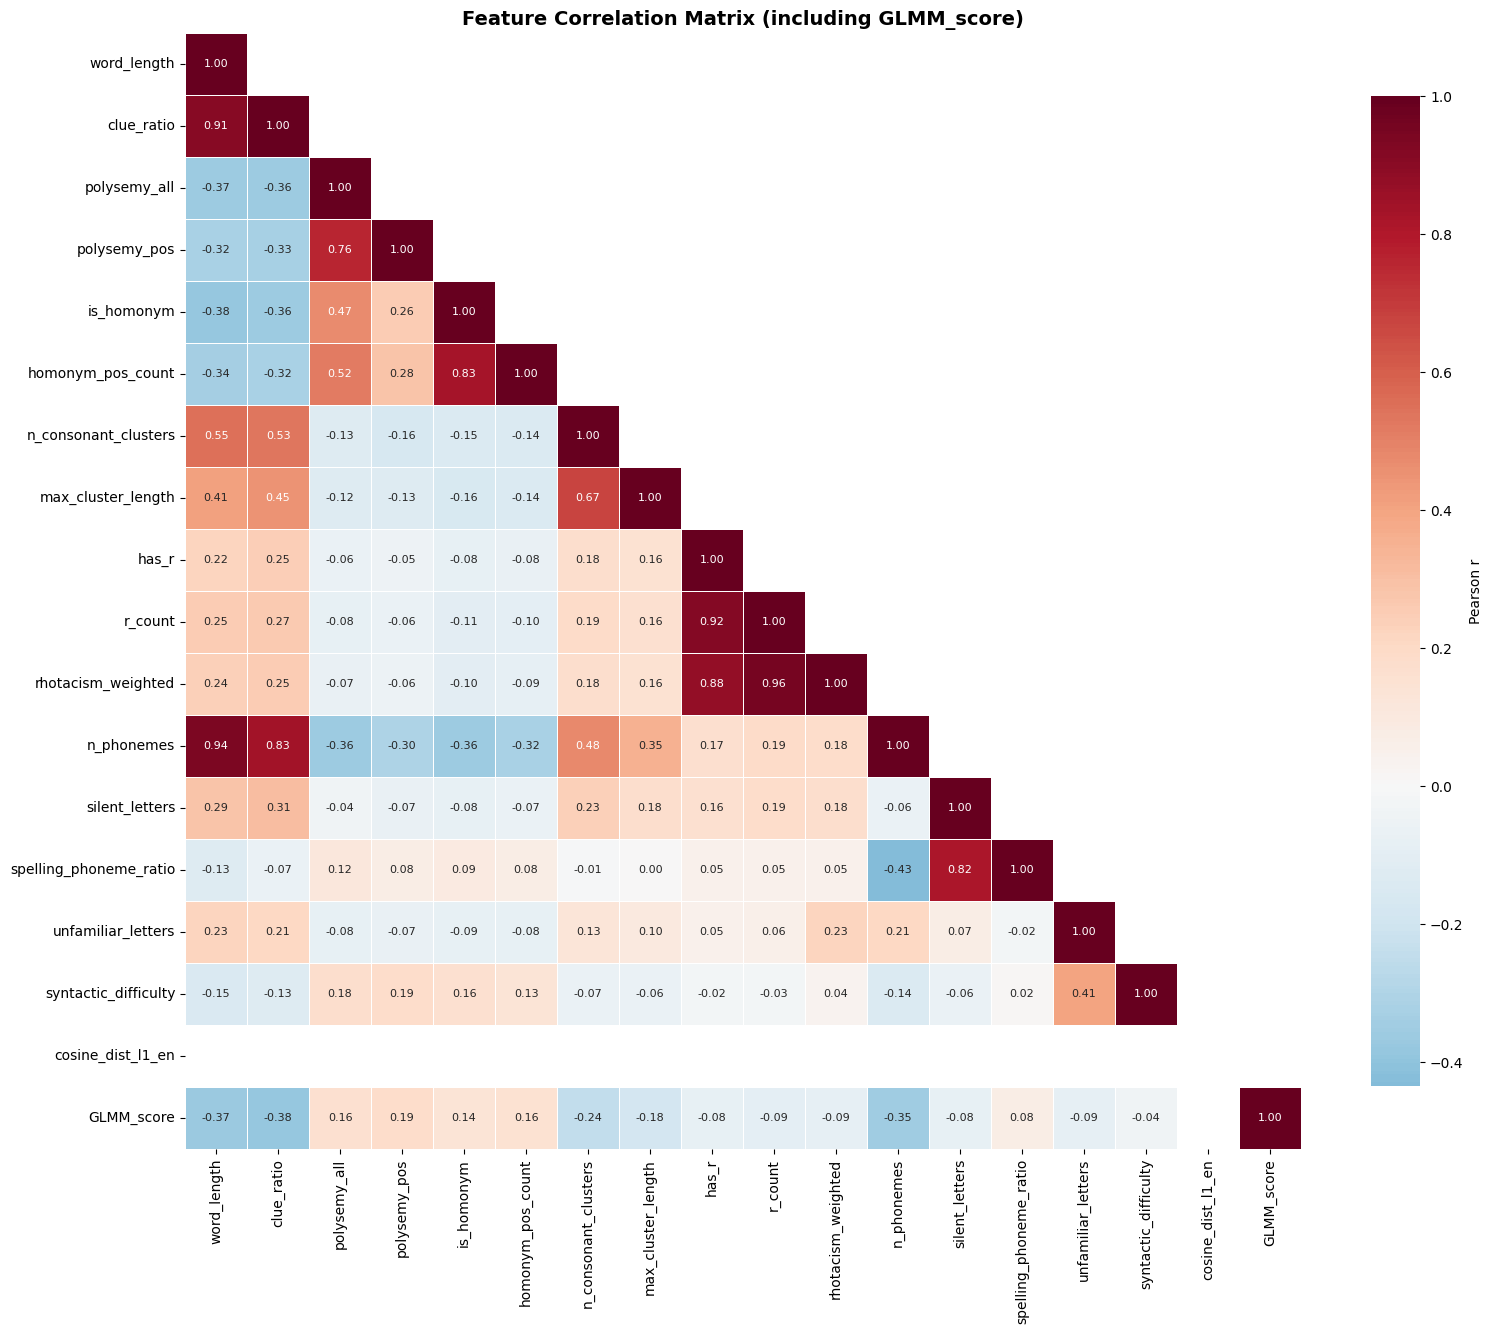


  FEATURE CORRELATIONS WITH GLMM_score
  clue_ratio                 r = -0.3815  ###############  (harder)
  word_length                r = -0.3687  ##############  (harder)
  n_phonemes                 r = -0.3533  ##############  (harder)
  n_consonant_clusters       r = -0.2435  #########  (harder)
  max_cluster_length         r = -0.1799  #######  (harder)
  r_count                    r = -0.0944  ###  (harder)
  rhotacism_weighted         r = -0.0920  ###  (harder)
  unfamiliar_letters         r = -0.0914  ###  (harder)
  has_r                      r = -0.0836  ###  (harder)
  silent_letters             r = -0.0783  ###  (harder)
  syntactic_difficulty       r = -0.0428  #  (harder)
  spelling_phoneme_ratio     r = +0.0771  ###  (easier)
  is_homonym                 r = +0.1374  #####  (easier)
  homonym_pos_count          r = +0.1567  ######  (easier)
  polysemy_all               r = +0.1608  ######  (easier)
  polysemy_pos               r = +0.1867  #######  (easier)

  FEATURE

In [ ]:
# ==============================================================================
# Feature Summary: Correlation Heatmap & Statistics
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

FEATURE_COLS = [
    "word_length",
    "clue_ratio",
    "polysemy_all",
    "polysemy_pos",
    "is_homonym",
    "homonym_pos_count",
    "n_consonant_clusters",
    "max_cluster_length",
    "has_r",
    "r_count",
    "rhotacism_weighted",
    "n_phonemes",
    "silent_letters",
    "spelling_phoneme_ratio",
    "unfamiliar_letters",
    "syntactic_difficulty",
    "cosine_dist_l1_en",
    "GLMM_score",
]

# Only include columns that exist
available_cols = [c for c in FEATURE_COLS if c in train.columns]
print(f"Available features: {len(available_cols) - 1} / {len(FEATURE_COLS) - 1}")

corr = train[available_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    annot_kws={"size": 8},
)
ax.set_title("Feature Correlation Matrix (including GLMM_score)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("  FEATURE CORRELATIONS WITH GLMM_score")
print("=" * 60)
target_corr = corr["GLMM_score"].drop("GLMM_score").dropna().sort_values()
for feat, r in target_corr.items():
    direction = "harder" if r < 0 else "easier"
    bar = "#" * int(abs(r) * 40)
    print(f"  {feat:25s}  r = {r:+.4f}  {bar}  ({direction})")

print("\n" + "=" * 60)
print("  FEATURE CORRELATIONS BY L1")
print("=" * 60)
for lang in ["es", "de", "cn"]:
    subset = train[train["L1"] == lang]
    lang_corr = subset[available_cols].corr()["GLMM_score"].drop("GLMM_score").dropna().sort_values()
    print(f"\n  L1 = {lang}:")
    if lang_corr.empty:
        print("    No valid correlations (all NaN).")
        continue
    for feat, r in lang_corr.items():
        print(f"    {feat:25s}  r = {r:+.4f}")

dropped = [c for c in available_cols if c != "GLMM_score" and c not in target_corr.index]
if dropped:
    print("\nNote: omitted NaN correlations:", dropped)

In [ ]:
# ==============================================================================
# Export Enriched DataFrames with All Features
# ==============================================================================

FEATURES_DIR = BASE / "data" / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# Save per-L1 enriched CSVs
for split_name, df in [("train", train), ("dev", dev)]:
    for lang in ["es", "de", "cn"]:
        subset = df[df["L1"] == lang]
        out_path = FEATURES_DIR / f"{lang}_{split_name}_features.csv"
        subset.to_csv(out_path, index=False)
        print(f"  ✓ Saved: {out_path} ({len(subset):,} rows, {len(subset.columns)} cols)")

# Save combined
train.to_csv(FEATURES_DIR / "all_train_features.csv", index=False)
dev.to_csv(FEATURES_DIR / "all_dev_features.csv", index=False)
print(f"\n  ✓ Combined train: {len(train):,} rows")
print(f"  ✓ Combined dev:   {len(dev):,} rows")
print(f"\nAll feature columns: {[c for c in train.columns if c not in ['item_id', 'L1', 'en_target_word', 'en_target_pos', 'en_target_clue', 'L1_source_word', 'L1_context', 'GLMM_score', 'split']]}")

  ✓ Saved: bea2026st\data\features\es_train_features.csv (6,091 rows, 30 cols)
  ✓ Saved: bea2026st\data\features\de_train_features.csv (6,091 rows, 30 cols)
  ✓ Saved: bea2026st\data\features\cn_train_features.csv (6,091 rows, 30 cols)
  ✓ Saved: bea2026st\data\features\es_dev_features.csv (677 rows, 30 cols)
  ✓ Saved: bea2026st\data\features\de_dev_features.csv (677 rows, 30 cols)
  ✓ Saved: bea2026st\data\features\cn_dev_features.csv (677 rows, 30 cols)

  ✓ Combined train: 18,273 rows
  ✓ Combined dev:   2,031 rows

All feature columns: ['word_length', 'clue_blanks', 'clue_ratio', 'polysemy_all', 'polysemy_pos', 'is_homonym', 'homonym_pos_count', 'n_consonant_clusters', 'max_cluster_length', 'has_r', 'r_count', 'rhotacism_weighted', 'n_phonemes', 'silent_letters', 'spelling_phoneme_ratio', 'unfamiliar_letters', 'has_unfamiliar', 'syntactic_difficulty', 'cosine_dist_l1_en', 'word_frequency', 'levenshtein_dist', 'morphological_complexity']


### 7. Optional: Improved L1-Specific Phonological Difficulty

This optional block keeps a stronger phonological feature design per L1 and is fully compatible with the cleaned workflow.

In [ ]:
# ==============================================================================
# Improved Feature: Phonological Difficulty per L1
# ==============================================================================
# Count English phonemes (from CMU Dict) that are ABSENT or DIFFICULT for each L1.
# This replaces / supplements the simplistic unfamiliar_letters feature.

# ARPAbet phonemes absent or systematically difficult for each L1
# Based on contrastive phonology literature (Avery & Ehrlich 1992; Swan & Smith 2001)

L1_DIFFICULT_PHONEMES = {
    "es": {
        # Phonemes absent/difficult for Spanish L1 speakers
        "TH",    # /θ/ (think) — doesn't exist in most Spanish dialects
        "DH",    # /ð/ (the)  — allophone only, not contrastive
        "V",     # /v/ (van)  — confused with /b/
        "Z",     # /z/ (zoo)  — allophone of /s/, not contrastive
        "ZH",    # /ʒ/ (measure) — doesn't exist
        "SH",    # /ʃ/ (ship) — marginal in most dialects
        "JH",    # /dʒ/ (judge) — doesn' exist in most dialects
        "NG",    # /ŋ/ (sing) — only in clusters, never final alone
        "IH",    # /ɪ/ (bit) — confused with /i:/
        "UH",    # /ʊ/ (book) — confused with /u:/
        "AE",    # /æ/ (cat) — doesn't exist
        "AH",    # /ʌ/ (cup) — confused with /a/
        "ER",    # /ɝ/ (bird) — rhotacized vowel doesn't exist
    },
    "de": {
        # Phonemes absent/difficult for German L1 speakers
        "TH",    # /θ/ (think) — doesn't exist
        "DH",    # /ð/ (the)  — doesn't exist
        "W",     # /w/ (wet)  — confused with /v/
        "ZH",    # /ʒ/ (measure) — marginal
        "AE",    # /æ/ (cat) — doesn't exist
        "ER",    # /ɝ/ (bird) — different r-coloring
    },
    "cn": {
        # Phonemes absent/difficult for Mandarin L1 speakers
        "TH",    # /θ/ (think) — doesn't exist
        "DH",    # /ð/ (the) — doesn't exist
        "V",     # /v/ (van) — doesn't exist
        "Z",     # /z/ (zoo) — doesn't exist as phoneme
        "ZH",    # /ʒ/ (measure) — doesn't exist
        "R",     # /ɹ/ (red) — very different from Mandarin r
        "L",     # /l/ (lip) — confused with /r/ in some positions
        "NG",    # /ŋ/ (sing) — exists in Mandarin but not syllable-initial
        "IH",    # /ɪ/ (bit) — merged with /i:/
        "UH",    # /ʊ/ (book) — merged with /u:/
        "AE",    # /æ/ (cat) — doesn't exist
        "AH",    # /ʌ/ (cup) — doesn't exist
        "ER",    # /ɝ/ (bird) — doesn't exist
        "OW",    # /oʊ/ (go) — diphthong difference
    },
}

# English grapheme patterns that are problematic per L1
L1_DIFFICULT_GRAPHEMES = {
    "es": ["th", "sh", "wh", "ght", "wr", "kn", "ph", "tch"],
    "de": ["th", "wh", "wr"],
    "cn": ["th", "sh", "ch", "wh", "ght", "wr", "kn", "ph", "tch", "tion", "sion"],
}

def count_difficult_phonemes(word, l1):
    """Count CMU phonemes in the English word that are difficult for the L1."""
    word_lower = word.lower()
    prons = CMU_DICT.get(word_lower)
    if not prons:
        return np.nan

    # Use first pronunciation
    phonemes = [p.rstrip("012") for p in prons[0]]  # strip stress markers
    difficult = L1_DIFFICULT_PHONEMES.get(l1, set())
    return sum(1 for ph in phonemes if ph in difficult)

def ratio_difficult_phonemes(word, l1):
    """Ratio of difficult phonemes to total phonemes."""
    word_lower = word.lower()
    prons = CMU_DICT.get(word_lower)
    if not prons:
        return np.nan
    phonemes = [p.rstrip("012") for p in prons[0]]
    if len(phonemes) == 0:
        return 0.0
    difficult = L1_DIFFICULT_PHONEMES.get(l1, set())
    return sum(1 for ph in phonemes if ph in difficult) / len(phonemes)

def count_difficult_graphemes(word, l1):
    """Count English letter patterns (digraphs/trigraphs) that are problematic for L1."""
    word_lower = word.lower()
    patterns = L1_DIFFICULT_GRAPHEMES.get(l1, [])
    return sum(word_lower.count(pat) for pat in patterns)

def count_final_clusters(word):
    """Count consonants in the final consonant cluster (hard for Mandarin speakers)."""
    word_lower = word.lower()
    vowels = set("aeiou")
    count = 0
    for ch in reversed(word_lower):
        if ch.isalpha() and ch not in vowels:
            count += 1
        elif ch in vowels:
            break
    return count

# Apply to train and dev
for df_name, df in [("train", train), ("dev", dev)]:
    df["difficult_phonemes"] = df.apply(
        lambda r: count_difficult_phonemes(r["en_target_word"], r["L1"]), axis=1
    )
    df["difficult_phoneme_ratio"] = df.apply(
        lambda r: ratio_difficult_phonemes(r["en_target_word"], r["L1"]), axis=1
    )
    df["difficult_graphemes"] = df.apply(
        lambda r: count_difficult_graphemes(r["en_target_word"], r["L1"]), axis=1
    )
    df["final_cluster_size"] = df["en_target_word"].apply(count_final_clusters)

    # Fill NaN for words not in CMU Dict
    df["difficult_phonemes"] = df["difficult_phonemes"].fillna(df["difficult_phonemes"].median())
    df["difficult_phoneme_ratio"] = df["difficult_phoneme_ratio"].fillna(df["difficult_phoneme_ratio"].median())

print("New phonological features computed:")
for lang in ["es", "de", "cn"]:
    subset = train[train["L1"] == lang]
    print(f"\n  L1={lang}:")
    print(f"    difficult_phonemes     mean={subset['difficult_phonemes'].mean():.2f}")
    print(f"    difficult_phoneme_ratio mean={subset['difficult_phoneme_ratio'].mean():.3f}")
    print(f"    difficult_graphemes    mean={subset['difficult_graphemes'].mean():.2f}")
    print(f"    final_cluster_size     mean={subset['final_cluster_size'].mean():.2f}")

# Correlations
print("\nCorrelation with GLMM_score:")
for feat in ["difficult_phonemes", "difficult_phoneme_ratio", "difficult_graphemes", "final_cluster_size"]:
    r = train[feat].corr(train["GLMM_score"])
    print(f"  {feat:30s}  r = {r:+.4f}")
    for lang in ["es", "de", "cn"]:
        sub = train[train["L1"] == lang]
        r_l1 = sub[feat].corr(sub["GLMM_score"])
        print(f"    L1={lang}: r = {r_l1:+.4f}")

# Examples
print("\nExamples:")
for word in ["think", "the", "rhythm", "knight", "cats", "strengths"]:
    for l1 in ["es", "de", "cn"]:
        dp = count_difficult_phonemes(word, l1)
        dg = count_difficult_graphemes(word, l1)
        fc = count_final_clusters(word)
        print(f"  {word:12s} (L1={l1}) → diff_phon={dp}, diff_graph={dg}, final_cluster={fc}")

New phonological features computed:

  L1=es:
    difficult_phonemes     mean=1.77
    difficult_phoneme_ratio mean=0.270
    difficult_graphemes    mean=0.09
    final_cluster_size     mean=1.24

  L1=de:
    difficult_phonemes     mean=0.42
    difficult_phoneme_ratio mean=0.075
    difficult_graphemes    mean=0.03
    final_cluster_size     mean=1.24

  L1=cn:
    difficult_phonemes     mean=2.39
    difficult_phoneme_ratio mean=0.377
    difficult_graphemes    mean=0.18
    final_cluster_size     mean=1.24

Correlation with GLMM_score:
  difficult_phonemes              r = -0.1802
    L1=es: r = -0.2223
    L1=de: r = +0.0082
    L1=cn: r = -0.3511
  difficult_phoneme_ratio         r = -0.0542
    L1=es: r = -0.1101
    L1=de: r = +0.0727
    L1=cn: r = -0.1298
  difficult_graphemes             r = -0.0133
    L1=es: r = +0.0228
    L1=de: r = +0.0280
    L1=cn: r = -0.0658
  final_cluster_size              r = -0.0163
    L1=es: r = -0.0279
    L1=de: r = -0.0083
    L1=cn: r = -0

In [ ]:
# ==============================================================================
# Re-export feature CSVs (now includes §8.0 phonological features)
# ==============================================================================
# The original export in §6.9 did NOT include the 4 features added above.
# This cell updates the feature CSVs with the complete feature set.

FEATURES_DIR = BASE / "data" / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

print("Re-exporting features with §8.0 phonological features included...")

for split_name, df in [("train", train), ("dev", dev)]:
    for lang in ["es", "de", "cn"]:
        subset = df[df["L1"] == lang]
        out_path = FEATURES_DIR / f"{lang}_{split_name}_features.csv"
        subset.to_csv(out_path, index=False)
        print(f"  ✓ {out_path.name}: {len(subset):,} rows × {len(subset.columns)} cols")

train.to_csv(FEATURES_DIR / "all_train_features.csv", index=False)
dev.to_csv(FEATURES_DIR / "all_dev_features.csv", index=False)

NEW_FEATURE_COLS = [c for c in train.columns if c not in [
    "item_id", "L1", "en_target_word", "en_target_pos", "en_target_clue",
    "L1_source_word", "L1_context", "GLMM_score", "split"
]]
print(f"\n✓ {len(NEW_FEATURE_COLS)} feature columns exported: {NEW_FEATURE_COLS}")

Re-exporting features with §8.0 phonological features included...


  ✓ es_train_features.csv: 6,091 rows × 34 cols
  ✓ de_train_features.csv: 6,091 rows × 34 cols
  ✓ cn_train_features.csv: 6,091 rows × 34 cols
  ✓ es_dev_features.csv: 677 rows × 34 cols
  ✓ de_dev_features.csv: 677 rows × 34 cols
  ✓ cn_dev_features.csv: 677 rows × 34 cols

✓ 26 feature columns exported: ['word_length', 'clue_blanks', 'clue_ratio', 'polysemy_all', 'polysemy_pos', 'is_homonym', 'homonym_pos_count', 'n_consonant_clusters', 'max_cluster_length', 'has_r', 'r_count', 'rhotacism_weighted', 'n_phonemes', 'silent_letters', 'spelling_phoneme_ratio', 'unfamiliar_letters', 'has_unfamiliar', 'syntactic_difficulty', 'cosine_dist_l1_en', 'word_frequency', 'levenshtein_dist', 'morphological_complexity', 'difficult_phonemes', 'difficult_phoneme_ratio', 'difficult_graphemes', 'final_cluster_size']


## 8. Final Presentation Tables and Plots

This final block keeps only what is needed to explain results clearly:

- Baseline vs XLM-RoBERTa-Large by language.
- Top feature correlations by language (feature engineering focus).

BASELINE vs XLM-R LARGE (OPEN TRACK)
           model L1   rmse  pearson
baseline_open_xx cn 1.0214   0.8042
baseline_open_xx de 1.1487   0.8004
baseline_open_xx es 1.2061   0.7873


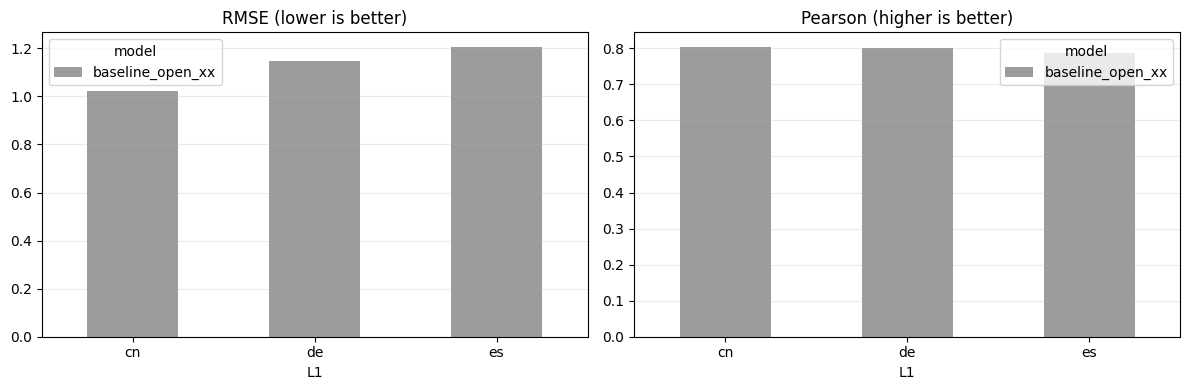


Top 6 feature correlations per L1:
L1                  feature    corr
es               clue_ratio -0.3498
es              word_length -0.3284
es morphological_complexity -0.2532
es     n_consonant_clusters -0.2515
es         levenshtein_dist -0.2453
es           word_frequency  0.2367
de         levenshtein_dist -0.3684
de               clue_ratio -0.3525
de              word_length -0.3440
de morphological_complexity -0.2503
de           word_frequency  0.2326
de     n_consonant_clusters -0.2203
cn           word_frequency  0.4881
cn               clue_ratio -0.4487
cn       unfamiliar_letters -0.4413
cn              word_length -0.4412
cn       difficult_phonemes -0.3511
cn             polysemy_pos  0.2684


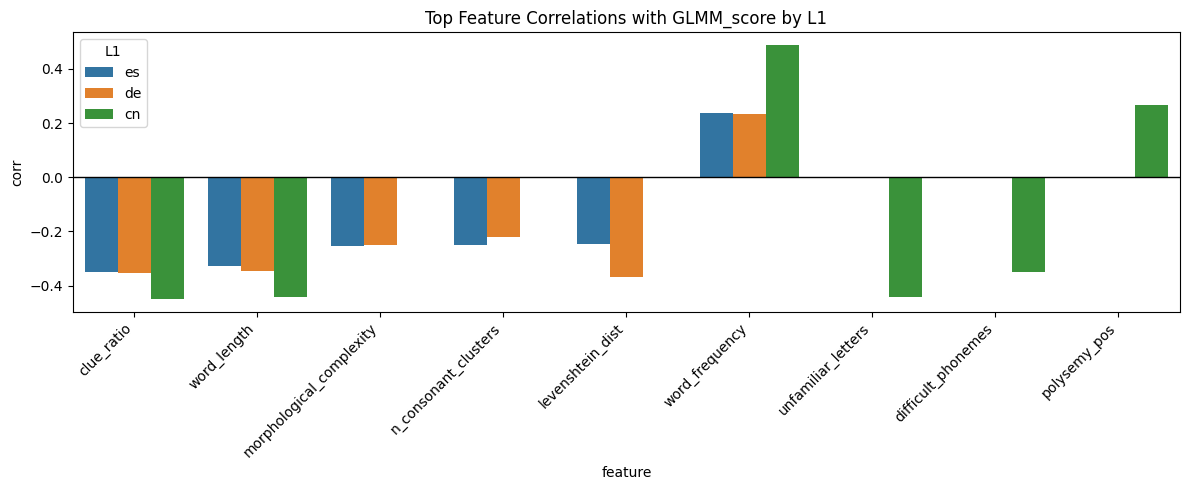

In [ ]:
# Final compact comparison: Baseline vs XLM-R large + feature view
import matplotlib.pyplot as plt
import seaborn as sns

baseline_csv = RESULTS_DIR / "results_summary_dev.csv"
phase1_csv = RESULTS_DIR / "results_summary_phase1_dev.csv"

if baseline_csv.exists() and phase1_csv.exists():
    baseline_df = pd.read_csv(baseline_csv)
    phase1_df = pd.read_csv(phase1_csv)

    baseline_open = baseline_df[
        (baseline_df["track"] == "open")
        & (baseline_df["model"] == "baseline_open_xx")
    ].copy()
    model_open = phase1_df[phase1_df["model"] == "exp1_open_xlmr_large"].copy()

    compare_df = pd.concat([baseline_open, model_open], ignore_index=True)
    compare_df = compare_df[["model", "L1", "rmse", "pearson"]].sort_values(["L1", "model"])

    print("=" * 70)
    print("BASELINE vs XLM-R LARGE (OPEN TRACK)")
    print("=" * 70)
    if compare_df.empty:
        print("No rows found for comparison.")
    else:
        print(compare_df.round(4).to_string(index=False))

    if model_open.empty:
        print("\nWARNING: XLM-R rows are missing in results_summary_phase1_dev.csv.")
        print("Run training/prediction for exp1_open_xlmr_large to obtain full comparison.")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, title in zip(
        axes,
        ["rmse", "pearson"],
        ["RMSE (lower is better)", "Pearson (higher is better)"],
    ):
        pivot = compare_df.pivot(index="L1", columns="model", values=metric)
        if "baseline_open_xx" in pivot.columns and "exp1_open_xlmr_large" in pivot.columns:
            pivot = pivot[["baseline_open_xx", "exp1_open_xlmr_large"]]
            colors = ["#9c9c9c", "#1f77b4"]
        elif "baseline_open_xx" in pivot.columns:
            pivot = pivot[["baseline_open_xx"]]
            colors = ["#9c9c9c"]
        else:
            ax.set_title(f"{title} (no baseline)")
            ax.axis("off")
            continue

        pivot.plot(kind="bar", rot=0, ax=ax, color=colors)
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.25)
        ax.set_xlabel("L1")

    plt.tight_layout()
    plt.show()
else:
    print("Missing results files. Run Phase 1 evaluation first.")

# Feature focus: top correlations by L1
candidate_cols = [
    "word_length", "clue_ratio", "polysemy_pos", "n_consonant_clusters",
    "rhotacism_weighted", "silent_letters", "spelling_phoneme_ratio",
    "unfamiliar_letters", "syntactic_difficulty", "cosine_dist_l1_en",
    "word_frequency", "levenshtein_dist", "morphological_complexity",
    "difficult_phonemes", "difficult_phoneme_ratio", "difficult_graphemes",
    "final_cluster_size",
]
available = [c for c in candidate_cols if c in train.columns]

if available:
    corr_rows = []
    for lang in ["es", "de", "cn"]:
        sub = train[train["L1"] == lang]
        corr = sub[available + ["GLMM_score"]].corr(numeric_only=True)["GLMM_score"].drop("GLMM_score")
        corr = corr.dropna()
        top = corr.reindex(corr.abs().sort_values(ascending=False).index).head(6)
        for feat, val in top.items():
            corr_rows.append({"L1": lang, "feature": feat, "corr": val})

    corr_df = pd.DataFrame(corr_rows)
    print("\nTop 6 feature correlations per L1:")
    if corr_df.empty:
        print("No valid feature correlations available.")
    else:
        print(corr_df.round(4).to_string(index=False))

        plt.figure(figsize=(12, 5))
        sns.barplot(data=corr_df, x="feature", y="corr", hue="L1")
        plt.xticks(rotation=45, ha="right")
        plt.title("Top Feature Correlations with GLMM_score by L1")
        plt.axhline(0, color="black", linewidth=1)
        plt.tight_layout()
        plt.show()

## 9. Export Essential HTML Report

This cell generates a compact HTML report with the key outcomes for presentation and sharing.

In [ ]:
from datetime import datetime
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("bea2026st/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

baseline_path = RESULTS_DIR / "results_summary_dev.csv"
phase1_path = RESULTS_DIR / "results_summary_phase1_dev.csv"
features_path = Path("bea2026st/data/features/all_train_features.csv")

def safe_read_csv(path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

def html_table(df):
    if df.empty:
        return "<p class='muted'>No data available.</p>"
    return df.to_html(index=False, border=0, classes="tbl", float_format=lambda x: f"{x:.4f}")

def img_tag(path, alt):
    if path.exists():
        return f"<img src='{path.name}' alt='{alt}' style='width:100%;border:1px solid #e5e7eb;border-radius:10px;'/>"
    return "<p class='muted'>Chart not available.</p>"

baseline_df = safe_read_csv(baseline_path)
phase1_df = safe_read_csv(phase1_path)

if not baseline_df.empty:
    baseline_open = baseline_df[
        (baseline_df.get("track", pd.Series(dtype=str)) == "open")
        & (baseline_df.get("model", pd.Series(dtype=str)) == "baseline_open_xx")
    ][["model", "L1", "rmse", "pearson"]].copy()
else:
    baseline_open = pd.DataFrame()

if not phase1_df.empty:
    xlmr_df = phase1_df[
        phase1_df.get("model", pd.Series(dtype=str)) == "exp1_open_xlmr_large"
    ][["model", "L1", "rmse", "pearson"]].copy()
else:
    xlmr_df = pd.DataFrame()

compare_df = pd.concat([baseline_open, xlmr_df], ignore_index=True) if (not baseline_open.empty or not xlmr_df.empty) else pd.DataFrame()
if not compare_df.empty:
    compare_df = compare_df.sort_values(["L1", "model"]).reset_index(drop=True)

# Delta table
delta_rows = []
if not compare_df.empty:
    for l1 in ["es", "de", "cn"]:
        base = compare_df[(compare_df["L1"] == l1) & (compare_df["model"] == "baseline_open_xx")]
        xlm = compare_df[(compare_df["L1"] == l1) & (compare_df["model"] == "exp1_open_xlmr_large")]
        if len(base) == 1 and len(xlm) == 1:
            b_rmse = float(base.iloc[0]["rmse"]); b_pearson = float(base.iloc[0]["pearson"])
            x_rmse = float(xlm.iloc[0]["rmse"]);  x_pearson = float(xlm.iloc[0]["pearson"])
            delta_rows.append({
                "L1": l1,
                "baseline_rmse": b_rmse,
                "xlmr_rmse": x_rmse,
                "delta_rmse": b_rmse - x_rmse,
                "baseline_pearson": b_pearson,
                "xlmr_pearson": x_pearson,
                "delta_pearson": x_pearson - b_pearson,
            })
delta_df = pd.DataFrame(delta_rows)

# Feature correlations table
if "train" in globals() and isinstance(train, pd.DataFrame):
    feat_df = train.copy()
else:
    feat_df = safe_read_csv(features_path)

candidate_cols = [
    "word_length", "clue_ratio", "polysemy_pos", "n_consonant_clusters",
    "rhotacism_weighted", "silent_letters", "spelling_phoneme_ratio",
    "unfamiliar_letters", "syntactic_difficulty", "cosine_dist_l1_en",
    "word_frequency", "levenshtein_dist", "morphological_complexity",
    "difficult_phonemes", "difficult_phoneme_ratio", "difficult_graphemes",
    "final_cluster_size",
]

feat_rows = []
if not feat_df.empty and "GLMM_score" in feat_df.columns and "L1" in feat_df.columns:
    available = [c for c in candidate_cols if c in feat_df.columns]
    for lang in ["es", "de", "cn"]:
        sub = feat_df[feat_df["L1"] == lang]
        if len(sub) > 3 and available:
            corr = sub[available + ["GLMM_score"]].corr(numeric_only=True)["GLMM_score"].drop("GLMM_score")
            top = corr.reindex(corr.abs().sort_values(ascending=False).index).head(6)
            for feat, val in top.items():
                feat_rows.append({"L1": lang, "feature": feat, "corr": float(val)})
top_feat_df = pd.DataFrame(feat_rows)

# Charts
metrics_chart = RESULTS_DIR / "report_baseline_vs_xlmr.png"
features_chart = RESULTS_DIR / "report_top_features_by_l1.png"

if not compare_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, title in zip(
        axes,
        ["rmse", "pearson"],
        ["RMSE (lower is better)", "Pearson (higher is better)"],
    ):
        pivot = compare_df.pivot(index="L1", columns="model", values=metric)
        if "baseline_open_xx" in pivot.columns and "exp1_open_xlmr_large" in pivot.columns:
            pivot = pivot[["baseline_open_xx", "exp1_open_xlmr_large"]]
        pivot.plot(kind="bar", rot=0, ax=ax, color=["#9c9c9c", "#1f77b4"])
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(metrics_chart, dpi=160, bbox_inches="tight")
    plt.close()

if not top_feat_df.empty:
    plt.figure(figsize=(12, 5))
    sns.barplot(data=top_feat_df, x="feature", y="corr", hue="L1")
    plt.xticks(rotation=45, ha="right")
    plt.title("Top Feature Correlations with GLMM_score by L1")
    plt.axhline(0, color="black", linewidth=1)
    plt.tight_layout()
    plt.savefig(features_chart, dpi=160, bbox_inches="tight")
    plt.close()

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M")
report_path = RESULTS_DIR / "final_summary_report.html"

html = f"""
<!doctype html>
<html lang='en'><head>
<meta charset='utf-8'/><meta name='viewport' content='width=device-width, initial-scale=1'/>
<title>BEA 2026 - Essential Report</title>
<style>
body {{font-family:Segoe UI,Tahoma,sans-serif;background:#f7f8fa;color:#1f2937;margin:0;}}
.wrap {{max-width:1100px;margin:24px auto;padding:0 16px;}}
.card {{background:#fff;border:1px solid #e5e7eb;border-radius:12px;padding:14px;margin-top:14px;}}
.hero {{background:linear-gradient(120deg,#e6fffa,#eef2ff);}}
.tbl {{width:100%;border-collapse:collapse;font-size:13px;}}
.tbl th,.tbl td {{border-bottom:1px solid #e5e7eb;padding:8px;text-align:left;}}
.tbl th {{background:#f9fafb;}}
.muted {{color:#6b7280;font-size:13px;}}
</style></head><body><div class='wrap'>
<div class='card hero'><h1>BEA 2026 Essential Report</h1>
<p class='muted'>Generated: {timestamp}</p>
<p class='muted'>Scope: Baseline vs XLM-RoBERTa-Large + feature engineering by L1.</p></div>
<div class='card'><h2>Baseline vs XLM-R Large (Open)</h2>{html_table(compare_df)}{img_tag(metrics_chart,'metrics')}</div>
<div class='card'><h2>Delta vs Baseline by L1</h2><p class='muted'>Positive deltas indicate improvement.</p>{html_table(delta_df)}</div>
<div class='card'><h2>Top Feature Correlations by L1</h2>{html_table(top_feat_df)}{img_tag(features_chart,'features')}</div>
<div class='card'><h2>Why XGBoost</h2><ul>
<li>Strong model for tabular linguistic features.</li>
<li>Captures non-linear interactions.</li>
<li>Fast and robust on CPU environments.</li>
<li>Interpretable via feature importance.</li>
<li>Complementary to transformer text models.</li>
</ul></div></div></body></html>
"""

report_path.write_text(html, encoding="utf-8")
print(f"HTML report saved: {report_path.resolve()}")
if metrics_chart.exists():
    print(f"Metrics chart saved: {metrics_chart.resolve()}")
if features_chart.exists():
    print(f"Features chart saved: {features_chart.resolve()}")

HTML report saved: C:\Users\adria\Documents\Doctorado\british_council\bea2026st\results\final_summary_report.html
Metrics chart saved: C:\Users\adria\Documents\Doctorado\british_council\bea2026st\results\report_baseline_vs_xlmr.png
Features chart saved: C:\Users\adria\Documents\Doctorado\british_council\bea2026st\results\report_top_features_by_l1.png


In [ ]:
# ==============================================================================
# Final artifact validation
# ==============================================================================

expected_files = [
    RESULTS_DIR / "results_summary_dev.csv",
    RESULTS_DIR / "results_summary_phase1_dev.csv",
    RESULTS_DIR / "final_summary_report.html",
    RESULTS_DIR / "report_baseline_vs_xlmr.png",
    RESULTS_DIR / "report_top_features_by_l1.png",
]

feature_files = [
    BASE / "data" / "features" / "es_train_features.csv",
    BASE / "data" / "features" / "de_train_features.csv",
    BASE / "data" / "features" / "cn_train_features.csv",
    BASE / "data" / "features" / "es_dev_features.csv",
    BASE / "data" / "features" / "de_dev_features.csv",
    BASE / "data" / "features" / "cn_dev_features.csv",
    BASE / "data" / "features" / "all_train_features.csv",
    BASE / "data" / "features" / "all_dev_features.csv",
]

print("=" * 70)
print("FINAL ARTIFACT CHECK")
print("=" * 70)

missing = []
for path in expected_files + feature_files:
    if path.exists():
        print(f"  [OK] {path}")
    else:
        print(f"  [MISSING] {path}")
        missing.append(path)

# XLM-R prediction contract
xlmr_preds = [
    PRED_DIR / "open" / "dev" / "es" / "exp1_open_xlmr_large_preds.csv",
    PRED_DIR / "open" / "dev" / "de" / "exp1_open_xlmr_large_preds.csv",
    PRED_DIR / "open" / "dev" / "cn" / "exp1_open_xlmr_large_preds.csv",
]

print("\nXLM-R prediction files:")
for path in xlmr_preds:
    if path.exists():
        print(f"  [OK] {path}")
    else:
        print(f"  [MISSING] {path}")
        missing.append(path)

if missing:
    print("\n⚠ Notebook executed, but some required artifacts are still missing.")
    print("   Re-run Phase 1 training/prediction and then evaluation/report cells.")
else:
    print("\n✓ All expected artifacts are present. Notebook is ready.")

FINAL ARTIFACT CHECK
  [OK] bea2026st\results\results_summary_dev.csv
  [OK] bea2026st\results\results_summary_phase1_dev.csv
  [OK] bea2026st\results\final_summary_report.html
  [OK] bea2026st\results\report_baseline_vs_xlmr.png
  [OK] bea2026st\results\report_top_features_by_l1.png
  [OK] bea2026st\data\features\es_train_features.csv
  [OK] bea2026st\data\features\de_train_features.csv
  [OK] bea2026st\data\features\cn_train_features.csv
  [OK] bea2026st\data\features\es_dev_features.csv
  [OK] bea2026st\data\features\de_dev_features.csv
  [OK] bea2026st\data\features\cn_dev_features.csv
  [OK] bea2026st\data\features\all_train_features.csv
  [OK] bea2026st\data\features\all_dev_features.csv

XLM-R prediction files:
  [MISSING] bea2026st\predictions\open\dev\es\exp1_open_xlmr_large_preds.csv
  [MISSING] bea2026st\predictions\open\dev\de\exp1_open_xlmr_large_preds.csv
  [MISSING] bea2026st\predictions\open\dev\cn\exp1_open_xlmr_large_preds.csv

⚠ Notebook executed, but some required a